# Maximum Likelihood Estimation: Complete Interactive Tutorial

**Course:** TTK 4260 - Multivariate Data Analysis and ML  
**Topic:** Lesson 05 - Maximum Likelihood Estimation  
**Instructor:** Adil Rasheed

---

## 📚 Table of Contents

1. [Prerequisites & Setup](#prerequisites)
2. [Part I: Motivation & Core Concepts](#part1)
   - 1.1 Probability vs. Likelihood
   - 1.2 The Coin Flip Example
3. [Part II: Mathematical Foundations](#part2)
   - 2.1 Formal MLE Definition
   - 2.2 The Score Function
   - 2.3 Fisher Information
   - 2.4 Asymptotic Properties of MLEs
4. [Part III: Distribution Toolkit with Full Derivations](#part3)
   - 3.1 Bernoulli Distribution
   - 3.2 Binomial Distribution
   - 3.3 Poisson Distribution
   - 3.4 Exponential Distribution
   - 3.5 Normal Distribution
   - 3.6 Distribution Selection Guide
5. [Part IV: MLE Properties](#part4)
   - 4.1 Bias of MLEs
   - 4.2 Invariance Property
6. [Part V: The ML = LS Connection](#part5)
7. [Part VI: Real-World Applications](#part6)
8. [Part VII: When MLE Fails](#part7)
9. [Part VIII: Model Diagnostics](#part8)
10. [Practice Exercises with Solutions](#exercises)
11. [Summary & Quick Reference](#summary)
12. [Glossary](#glossary)

---

<a id='prerequisites'></a>
## 📋 Prerequisites

### Mathematical Background Required

| Topic | Concepts Needed |
|-------|----------------|
| **Calculus** | Derivatives, partial derivatives, chain rule, finding maxima/minima |
| **Probability** | Random variables, PDFs, PMFs, expected value, variance |
| **Statistics** | Sample mean, sample variance, confidence intervals |
| **Linear Algebra** | Matrix multiplication, transpose, inverse (for regression) |

### Learning Objectives

By the end of this notebook, you will be able to:

1. ✅ Explain the difference between **probability** and **likelihood**
2. ✅ State and apply the **Maximum Likelihood Principle**
3. ✅ Derive MLEs for common distributions from scratch
4. ✅ Understand the **score function** and **Fisher information**
5. ✅ Explain **asymptotic properties**: consistency, efficiency, normality
6. ✅ Apply the **invariance property** of MLEs
7. ✅ Understand why **ML = LS** under Gaussian noise
8. ✅ Recognize when MLE fails and apply robust alternatives
9. ✅ Apply MLE to real-world problems

---

## Setup: Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize, minimize_scalar
from scipy.special import comb
import seaborn as sns
from ipywidgets import interact, FloatSlider, IntSlider
import warnings

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')
np.random.seed(42)

# Helper function for nice boxes
def print_box(title, content, emoji="📌"):
    print(f"\n{emoji} {title}")
    print("─" * 50)
    if isinstance(content, list):
        for item in content:
            print(f"  • {item}")
    else:
        print(f"  {content}")
    print("─" * 50)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---
<a id='part1'></a>
# Part I: Motivation & Core Concepts

## The Fundamental Question in Data Science

> **Given observed data, what are the best parameters to describe the underlying process that generated this data?**

This is the central question that Maximum Likelihood Estimation answers.

### Example: The Coin Flip Problem

You flip a coin 10 times and observe 7 heads. What is the probability $p$ that this coin lands heads?

**What this code does:**
1. Displays the observed data from our coin flip experiment
2. Calculates a naive estimate by dividing heads by total flips
3. Sets up the question we'll answer rigorously with MLE

In [2]:
# Simple coin flip example
n_flips = 10
n_heads = 7

print(f"Experiment: {n_flips} coin flips")
print(f"Result: {n_heads} heads, {n_flips - n_heads} tails")
print(f"\nNaive estimate: p = {n_heads}/{n_flips} = {n_heads/n_flips:.2f}")
print("\nBut how confident are we? Let's find out using Maximum Likelihood!")

Experiment: 10 coin flips
Result: 7 heads, 3 tails

Naive estimate: p = 7/10 = 0.70

But how confident are we? Let's find out using Maximum Likelihood!


---
## 1.1 Probability vs. Likelihood: The Key Distinction

This is perhaps the **most important conceptual distinction** in this entire course.

---

### 🎯 The Same Formula, Two Different Questions

Consider the function $f(x|\theta)$. The **same mathematical expression** answers two different questions:

| Aspect | **Probability** $P(x\|\theta)$ | **Likelihood** $L(\theta\|x)$ |
|--------|-------------------------------|------------------------------|
| **What's fixed?** | Parameters $\theta$ | Data $x$ |
| **What varies?** | Data $x$ | Parameters $\theta$ |
| **Question answered** | "Given these parameters, what data might I observe?" | "Given this data, which parameters are most plausible?" |
| **When used** | Before collecting data (prediction) | After collecting data (inference) |
| **Integrates to 1?** | ✓ Yes (over all possible data) | ✗ No (over parameters) |
| **Can compare values?** | Gives actual probabilities | Only ratios are meaningful |

---

### ⚠️ Common Misconception

**❌ WRONG:** 
> "The likelihood is 0.27, so there's a 27% chance the parameter equals this value."

**✅ RIGHT:** 
> "The likelihood at this parameter value is 0.27. This is 3× higher than at another value (0.09), so this parameter is 3× more plausible."

---

### 📊 Interactive Visualization

**What this code does:**
1. ✓ Creates side-by-side plots comparing probability and likelihood views
2. ✓ **LEFT plot:** Fixes parameters (μ, σ), shows distribution over possible data values
3. ✓ **RIGHT plot:** Fixes observed data, shows likelihood across different parameter values
4. ✓ Demonstrates that the likelihood peak occurs at the MLE

**Use the sliders below to explore:**

In [3]:
def plot_probability_vs_likelihood(mu=0, sigma=1, observed_x=1.5):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # === LEFT: Probability view ===
    x_range = np.linspace(-4, 4, 200)
    prob_density = stats.norm.pdf(x_range, mu, sigma)
    
    ax1.plot(x_range, prob_density, 'b-', linewidth=2)
    ax1.fill_between(x_range, prob_density, alpha=0.3)
    ax1.axvline(observed_x, color='red', linestyle='--', linewidth=2, label=f'Observed x={observed_x}')
    ax1.set_xlabel('x (data)', fontsize=12)
    ax1.set_ylabel('P(x | μ, σ)', fontsize=12)
    ax1.set_title(f'PROBABILITY VIEW\nParameters fixed: μ={mu}, σ={sigma}', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.set_ylim(bottom=0)
    
    # Area annotation
    area = np.trapz(prob_density, x_range)
    ax1.text(0.02, 0.98, f'Area under curve ≈ {area:.2f}', transform=ax1.transAxes, 
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue'))
    
    # === RIGHT: Likelihood view ===
    mu_range = np.linspace(-2, 4, 200)
    likelihood = stats.norm.pdf(observed_x, mu_range, sigma)
    
    ax2.plot(mu_range, likelihood, 'r-', linewidth=2)
    ax2.fill_between(mu_range, likelihood, alpha=0.3, color='red')
    
    mle_mu = observed_x
    ax2.axvline(mle_mu, color='darkred', linestyle='--', linewidth=2)
    ax2.plot(mle_mu, stats.norm.pdf(observed_x, mle_mu, sigma), 'ko', markersize=10, label=f'MLE: μ̂={mle_mu:.2f}')
    
    ax2.set_xlabel('μ (parameter)', fontsize=12)
    ax2.set_ylabel('L(μ | x)', fontsize=12)
    ax2.set_title(f'LIKELIHOOD VIEW\nData fixed: x={observed_x}', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.set_ylim(bottom=0)
    
    area_lik = np.trapz(likelihood, mu_range)
    ax2.text(0.02, 0.98, f'Area under curve ≈ {area_lik:.2f} ≠ 1', transform=ax2.transAxes, 
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow'))
    
    plt.tight_layout()
    plt.show()
    
    print_box("Key Insight", [
        "LEFT: Area under curve = 1 (it's a probability distribution)",
        "RIGHT: Area ≠ 1 (it's a likelihood function, NOT a probability)",
        f"MLE finds the μ that maximizes the likelihood: μ̂_ML = {mle_mu:.2f}",
        "Likelihood values are only meaningful as RATIOS, not absolute values"
    ], "🎯")

# Create interactive widget
interact(plot_probability_vs_likelihood,
         mu=FloatSlider(min=-2, max=2, step=0.5, value=0, description='μ:'),
         sigma=FloatSlider(min=0.5, max=2, step=0.5, value=1, description='σ:'),
         observed_x=FloatSlider(min=-2, max=4, step=0.5, value=1.5, description='Observed x:'));

interactive(children=(FloatSlider(value=0.0, description='μ:', max=2.0, min=-2.0, step=0.5), FloatSlider(value…

### 🧠 Self-Check Question 1

If $L(\theta_1 | x) = 0.04$ and $L(\theta_2 | x) = 0.01$, what can we conclude?

<details>
<summary>Click for answer</summary>

We can conclude that $\theta_1$ is **4 times more plausible** than $\theta_2$ given the observed data.

We **cannot** say there's a "4% chance" that $\theta = \theta_1$ — likelihood is not probability!
</details>

---

## 1.2 The Coin Flip Example: Computing the Likelihood

Let's return to our coin flip example and compute the likelihood function step by step.

### The Setup

- We flip a coin $n = 10$ times
- We observe $k = 7$ heads
- We want to find the most likely value of $p$ (probability of heads)

### The Likelihood Function

The probability of observing exactly $k$ heads in $n$ flips, given probability $p$, is:

$$P(k \text{ heads} | p) = \binom{n}{k} p^k (1-p)^{n-k}$$

When viewed as a function of $p$ (with $k$ and $n$ fixed), this becomes the **likelihood function**:

$$L(p | k, n) = \binom{n}{k} p^k (1-p)^{n-k}$$

**What this code does:**
1. Defines the likelihood function for binomial data
2. Evaluates it across all possible values of $p$
3. Finds the value of $p$ that maximizes the likelihood (the MLE)
4. Plots the likelihood curve with the MLE marked

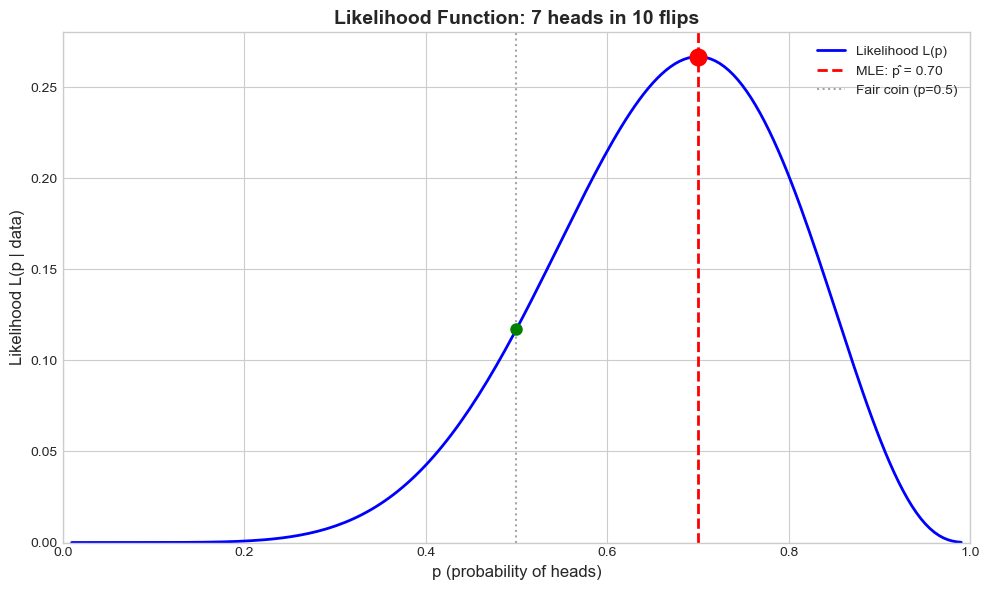


📊 Results:
   Observed: 7 heads in 10 flips
   MLE (numerical): p̂ = 0.699
   MLE (analytical): p̂ = 7/10 = 0.700

   Likelihood at MLE: L(0.70) = 0.2668
   Likelihood at p=0.5: L(0.5) = 0.1172

   Likelihood ratio: L(MLE)/L(0.5) = 2.28
   → p = 0.7 is 2.3× more plausible than p = 0.5


In [4]:
def binomial_likelihood(p, k, n):
    return comb(n, k, exact=True) * (p ** k) * ((1 - p) ** (n - k))

n_flips = 10
n_heads = 7

p_values = np.linspace(0.01, 0.99, 200)
likelihoods = [binomial_likelihood(p, n_heads, n_flips) for p in p_values]

mle_index = np.argmax(likelihoods)
p_mle = p_values[mle_index]
max_likelihood = likelihoods[mle_index]
p_mle_analytical = n_heads / n_flips

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p_values, likelihoods, 'b-', linewidth=2, label='Likelihood L(p)')
ax.axvline(p_mle, color='red', linestyle='--', linewidth=2, label=f'MLE: p̂ = {p_mle:.2f}')
ax.plot(p_mle, max_likelihood, 'ro', markersize=12)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Fair coin (p=0.5)')
fair_likelihood = binomial_likelihood(0.5, n_heads, n_flips)
ax.plot(0.5, fair_likelihood, 'go', markersize=8)

ax.set_xlabel('p (probability of heads)', fontsize=12)
ax.set_ylabel('Likelihood L(p | data)', fontsize=12)
ax.set_title(f'Likelihood Function: {n_heads} heads in {n_flips} flips', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

print(f"\n📊 Results:")
print(f"   Observed: {n_heads} heads in {n_flips} flips")
print(f"   MLE (numerical): p̂ = {p_mle:.3f}")
print(f"   MLE (analytical): p̂ = {n_heads}/{n_flips} = {p_mle_analytical:.3f}")
print(f"\n   Likelihood at MLE: L({p_mle:.2f}) = {max_likelihood:.4f}")
print(f"   Likelihood at p=0.5: L(0.5) = {fair_likelihood:.4f}")
print(f"\n   Likelihood ratio: L(MLE)/L(0.5) = {max_likelihood/fair_likelihood:.2f}")
print(f"   → p = 0.7 is {max_likelihood/fair_likelihood:.1f}× more plausible than p = 0.5")

---
<a id='part2'></a>
# Part II: Mathematical Foundations

Now let's formalize the concepts we've introduced.

## 2.1 Formal MLE Definition

### Definition: Maximum Likelihood Estimator

Given:
- Observed data: $\mathbf{x} = (x_1, x_2, \ldots, x_n)$
- Assumed distribution with PDF/PMF: $f(x | \theta)$
- Unknown parameter(s): $\theta$

The **likelihood function** is:
$$L(\theta | \mathbf{x}) = \prod_{i=1}^{n} f(x_i | \theta)$$

The **Maximum Likelihood Estimator (MLE)** is:
$$\boxed{\hat{\theta}_{\text{ML}} = \arg\max_{\theta} L(\theta | \mathbf{x})}$$

### Why Use Log-Likelihood?

In practice, we maximize the **log-likelihood** $\ell(\theta) = \log L(\theta)$:

$$\ell(\theta | \mathbf{x}) = \sum_{i=1}^{n} \log f(x_i | \theta)$$

**Reasons:**

| Issue with $L(\theta)$ | Solution with $\ell(\theta)$ |
|------------------------|------------------------------|
| Products of small numbers → numerical underflow | Sums of log values → stable |
| Product rule for derivatives → messy | Sum rule → clean |
| Hard to work with analytically | Easier algebra |

**Key fact:** Since $\log$ is monotonically increasing:
$$\arg\max_{\theta} L(\theta) = \arg\max_{\theta} \ell(\theta)$$

In [5]:
# Demonstrate numerical stability: Likelihood vs Log-Likelihood
np.random.seed(42)
data = np.random.normal(5, 2, 100)

def compute_likelihood_product(data, mu, sigma):
    likelihood = 1.0
    for x in data:
        likelihood *= stats.norm.pdf(x, mu, sigma)
    return likelihood

def compute_log_likelihood_sum(data, mu, sigma):
    return np.sum(stats.norm.logpdf(data, mu, sigma))

mu_test, sigma_test = 5.0, 2.0
likelihood_product = compute_likelihood_product(data, mu_test, sigma_test)
log_likelihood_sum = compute_log_likelihood_sum(data, mu_test, sigma_test)

print("🔢 Numerical Stability Demonstration")
print("─" * 50)
print(f"Data: {len(data)} observations from N(5, 4)")
print(f"\nLikelihood (product): L = {likelihood_product}")
print(f"Log-likelihood (sum): ℓ = {log_likelihood_sum:.2f}")
print(f"\n⚠️  Notice: The product underflowed to 0!")
print(f"   This is why we ALWAYS use log-likelihood in practice.")

🔢 Numerical Stability Demonstration
──────────────────────────────────────────────────
Data: 100 observations from N(5, 4)

Likelihood (product): L = 1.0550647227001337e-88
Log-likelihood (sum): ℓ = -202.57

⚠️  Notice: The product underflowed to 0!
   This is why we ALWAYS use log-likelihood in practice.


---
## 2.2 The Score Function

### Definition

The **score function** (or **score**) is the gradient of the log-likelihood:

$$\boxed{s(\theta) = \frac{\partial \ell(\theta)}{\partial \theta} = \frac{\partial}{\partial \theta} \log L(\theta)}$$

For multiple parameters $\boldsymbol{\theta} = (\theta_1, \ldots, \theta_k)$, the score is a vector:

$$\mathbf{s}(\boldsymbol{\theta}) = \nabla_{\boldsymbol{\theta}} \ell(\boldsymbol{\theta}) = \begin{pmatrix} \frac{\partial \ell}{\partial \theta_1} \\ \vdots \\ \frac{\partial \ell}{\partial \theta_k} \end{pmatrix}$$

### The Score Equation

At the MLE, the score equals zero:

$$\boxed{s(\hat{\theta}_{\text{ML}}) = 0}$$

This is the **first-order condition** (necessary condition) for a maximum.

### Important Properties of the Score

1. **Expected value is zero** at the true parameter:
   $$E[s(\theta_0)] = 0$$
   
2. **Variance equals Fisher information**:
   $$\text{Var}[s(\theta_0)] = I(\theta_0)$$

### ⚠️ Important Caveat

The score equation $s(\theta) = 0$ is **necessary but not sufficient** for a maximum:
- It could be a minimum (second derivative > 0)
- It could be a saddle point
- The maximum could be at a boundary

**Second-order condition**: Must verify $\frac{\partial^2 \ell}{\partial \theta^2} < 0$ at the solution.

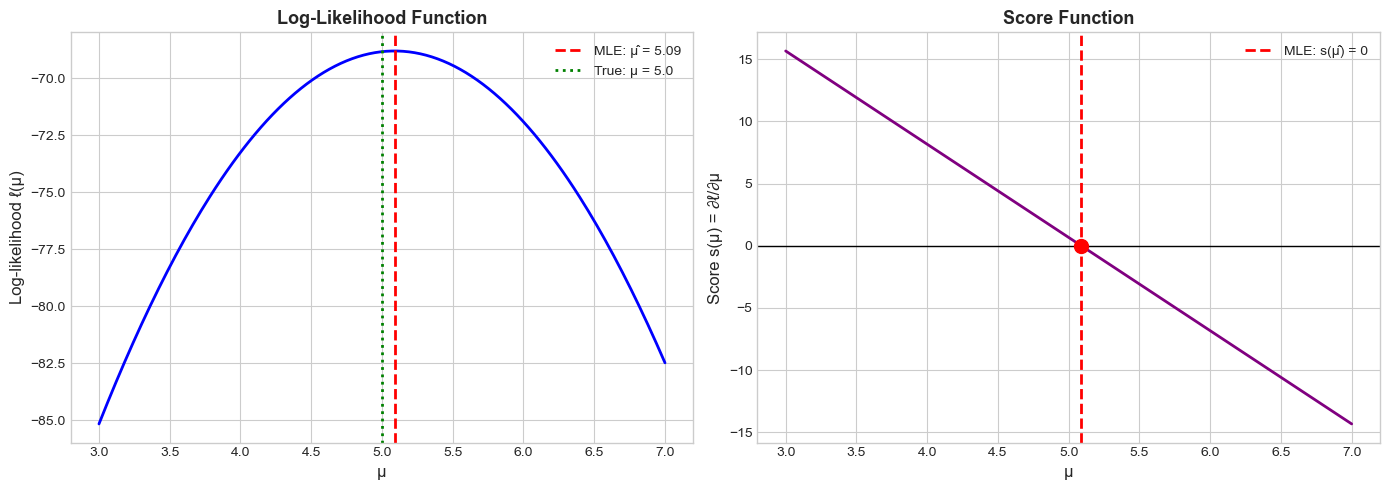


🎯 Key Observations
──────────────────────────────────────────────────
  • The log-likelihood is maximized at μ̂ = 5.089
  • The score function crosses zero at this same point
  • Score equation: s(μ̂) = Σ(xᵢ - μ̂)/σ² = 0
  • Solving: μ̂ = (1/n)Σxᵢ = x̄ = 5.089
──────────────────────────────────────────────────


In [6]:
# Visualize the Score Function for Normal Distribution
np.random.seed(123)
true_mu = 5.0
true_sigma = 2.0
n = 30
data = np.random.normal(true_mu, true_sigma, n)
sample_mean = np.mean(data)

def log_likelihood_mu(mu, data, sigma):
    n = len(data)
    return -n/2 * np.log(2*np.pi*sigma**2) - np.sum((data - mu)**2) / (2*sigma**2)

def score_mu(mu, data, sigma):
    return np.sum(data - mu) / sigma**2

mu_range = np.linspace(3, 7, 200)
log_lik_values = [log_likelihood_mu(mu, data, true_sigma) for mu in mu_range]
score_values = [score_mu(mu, data, true_sigma) for mu in mu_range]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(mu_range, log_lik_values, 'b-', linewidth=2)
ax1.axvline(sample_mean, color='red', linestyle='--', linewidth=2, label=f'MLE: μ̂ = {sample_mean:.2f}')
ax1.axvline(true_mu, color='green', linestyle=':', linewidth=2, label=f'True: μ = {true_mu}')
ax1.set_xlabel('μ', fontsize=12)
ax1.set_ylabel('Log-likelihood ℓ(μ)', fontsize=12)
ax1.set_title('Log-Likelihood Function', fontsize=13, fontweight='bold')
ax1.legend()

ax2.plot(mu_range, score_values, 'purple', linewidth=2)
ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.axvline(sample_mean, color='red', linestyle='--', linewidth=2, label=f'MLE: s(μ̂) = 0')
ax2.plot(sample_mean, 0, 'ro', markersize=10)
ax2.set_xlabel('μ', fontsize=12)
ax2.set_ylabel('Score s(μ) = ∂ℓ/∂μ', fontsize=12)
ax2.set_title('Score Function', fontsize=13, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print_box("Key Observations", [
    f"The log-likelihood is maximized at μ̂ = {sample_mean:.3f}",
    f"The score function crosses zero at this same point",
    f"Score equation: s(μ̂) = Σ(xᵢ - μ̂)/σ² = 0",
    f"Solving: μ̂ = (1/n)Σxᵢ = x̄ = {sample_mean:.3f}"
], "🎯")

---
## 2.3 Fisher Information

### Definition

The **Fisher Information** measures how much information the data carries about the parameter.

$$\boxed{I(\theta) = E\left[\left(\frac{\partial \ell}{\partial \theta}\right)^2\right] = -E\left[\frac{\partial^2 \ell}{\partial \theta^2}\right]}$$

For $n$ i.i.d. observations: $I_n(\theta) = n \cdot I_1(\theta)$

### Why Fisher Information Matters

1. **Cramér-Rao Lower Bound**: For any unbiased estimator $\hat{\theta}$:
   $$\text{Var}(\hat{\theta}) \geq \frac{1}{I(\theta)}$$
   
   The MLE achieves this bound asymptotically (it's **efficient**).

2. **Confidence Intervals**: Asymptotically:
   $$\hat{\theta}_{\text{ML}} \sim N\left(\theta, \frac{1}{I(\theta)}\right)$$
   
   So a 95% CI is approximately:
   $$\hat{\theta}_{\text{ML}} \pm 1.96 \cdot \frac{1}{\sqrt{I(\hat{\theta})}}$$

3. **Intuition**: High Fisher information = data is very informative = lower variance estimates

### Fisher Information for Common Distributions

| Distribution | Parameter | Fisher Information $I(\theta)$ |
|-------------|-----------|-------------------------------|
| Bernoulli$(p)$ | $p$ | $\frac{1}{p(1-p)}$ |
| Poisson$(\lambda)$ | $\lambda$ | $\frac{1}{\lambda}$ |
| Normal$(\mu, \sigma^2)$ | $\mu$ (σ known) | $\frac{1}{\sigma^2}$ |
| Normal$(\mu, \sigma^2)$ | $\sigma^2$ (μ known) | $\frac{1}{2\sigma^4}$ |
| Exponential$(\lambda)$ | $\lambda$ | $\frac{1}{\lambda^2}$ |

📊 Fisher Information and Cramér-Rao Bound
════════════════════════════════════════════════════════════
True parameter: p = 0.3
Fisher Information (per obs): I₁(p) = 1/[p(1-p)] = 4.762

------------------------------------------------------------
     n |     CR Bound |  Simulated Var |    Ratio
------------------------------------------------------------
    10 |     0.021000 |       0.021350 |    1.017
    30 |     0.007000 |       0.006893 |    0.985


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


   100 |     0.002100 |       0.002065 |    0.983
   300 |     0.000700 |       0.000691 |    0.987
  1000 |     0.000210 |       0.000203 |    0.965
------------------------------------------------------------
Note: Ratio ≈ 1 means MLE achieves the Cramér-Rao bound (efficient)


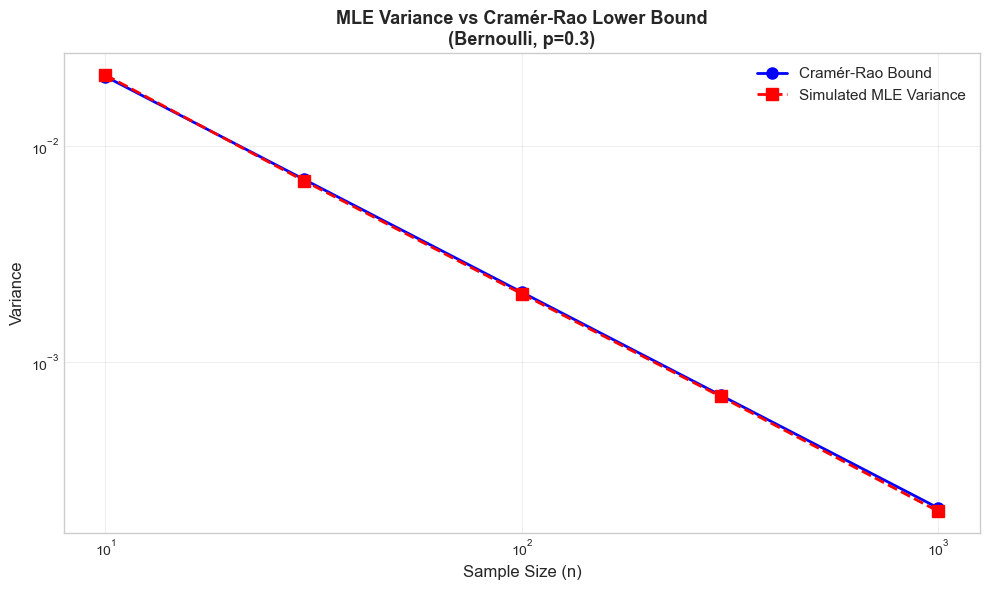

In [7]:
# Demonstrate Fisher Information and Cramér-Rao Bound
def simulate_mle_variance(true_p, n_samples, n_simulations=1000):
    mle_estimates = []
    for _ in range(n_simulations):
        data = np.random.binomial(1, true_p, n_samples)
        p_hat = np.mean(data)
        mle_estimates.append(p_hat)
    return np.array(mle_estimates)

true_p = 0.3
sample_sizes = [10, 30, 100, 300, 1000]
fisher_info_single = 1 / (true_p * (1 - true_p))

print("📊 Fisher Information and Cramér-Rao Bound")
print("═" * 60)
print(f"True parameter: p = {true_p}")
print(f"Fisher Information (per obs): I₁(p) = 1/[p(1-p)] = {fisher_info_single:.3f}")
print("\n" + "-" * 60)
print(f"{'n':>6} | {'CR Bound':>12} | {'Simulated Var':>14} | {'Ratio':>8}")
print("-" * 60)

simulated_vars = []
cr_bounds = []

for n in sample_sizes:
    cr_bound = 1 / (n * fisher_info_single)
    cr_bounds.append(cr_bound)
    
    estimates = simulate_mle_variance(true_p, n)
    sim_var = np.var(estimates)
    simulated_vars.append(sim_var)
    
    ratio = sim_var / cr_bound
    print(f"{n:>6} | {cr_bound:>12.6f} | {sim_var:>14.6f} | {ratio:>8.3f}")

print("-" * 60)
print("Note: Ratio ≈ 1 means MLE achieves the Cramér-Rao bound (efficient)")

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(sample_sizes, cr_bounds, 'b-o', linewidth=2, markersize=8, label='Cramér-Rao Bound')
ax.loglog(sample_sizes, simulated_vars, 'r--s', linewidth=2, markersize=8, label='Simulated MLE Variance')
ax.set_xlabel('Sample Size (n)', fontsize=12)
ax.set_ylabel('Variance', fontsize=12)
ax.set_title('MLE Variance vs Cramér-Rao Lower Bound\n(Bernoulli, p=0.3)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2.4 Asymptotic Properties of MLEs

Under regularity conditions, MLEs have remarkable properties as $n \to \infty$:

### 1. Consistency
$$\hat{\theta}_{\text{ML}} \xrightarrow{P} \theta_0 \text{ as } n \to \infty$$

The MLE converges in probability to the true value.

### 2. Asymptotic Normality
$$\sqrt{n}(\hat{\theta}_{\text{ML}} - \theta_0) \xrightarrow{d} N\left(0, \frac{1}{I_1(\theta_0)}\right)$$

Equivalently:
$$\hat{\theta}_{\text{ML}} \stackrel{\text{approx}}{\sim} N\left(\theta_0, \frac{1}{n \cdot I_1(\theta_0)}\right)$$

### 3. Efficiency
The MLE achieves the Cramér-Rao lower bound asymptotically.

### Interactive Visualization: Watching Consistency in Action

**What this code does:**
1. Simulates Poisson data with increasing sample sizes
2. Shows how the MLE distribution concentrates around the true value
3. Demonstrates asymptotic normality

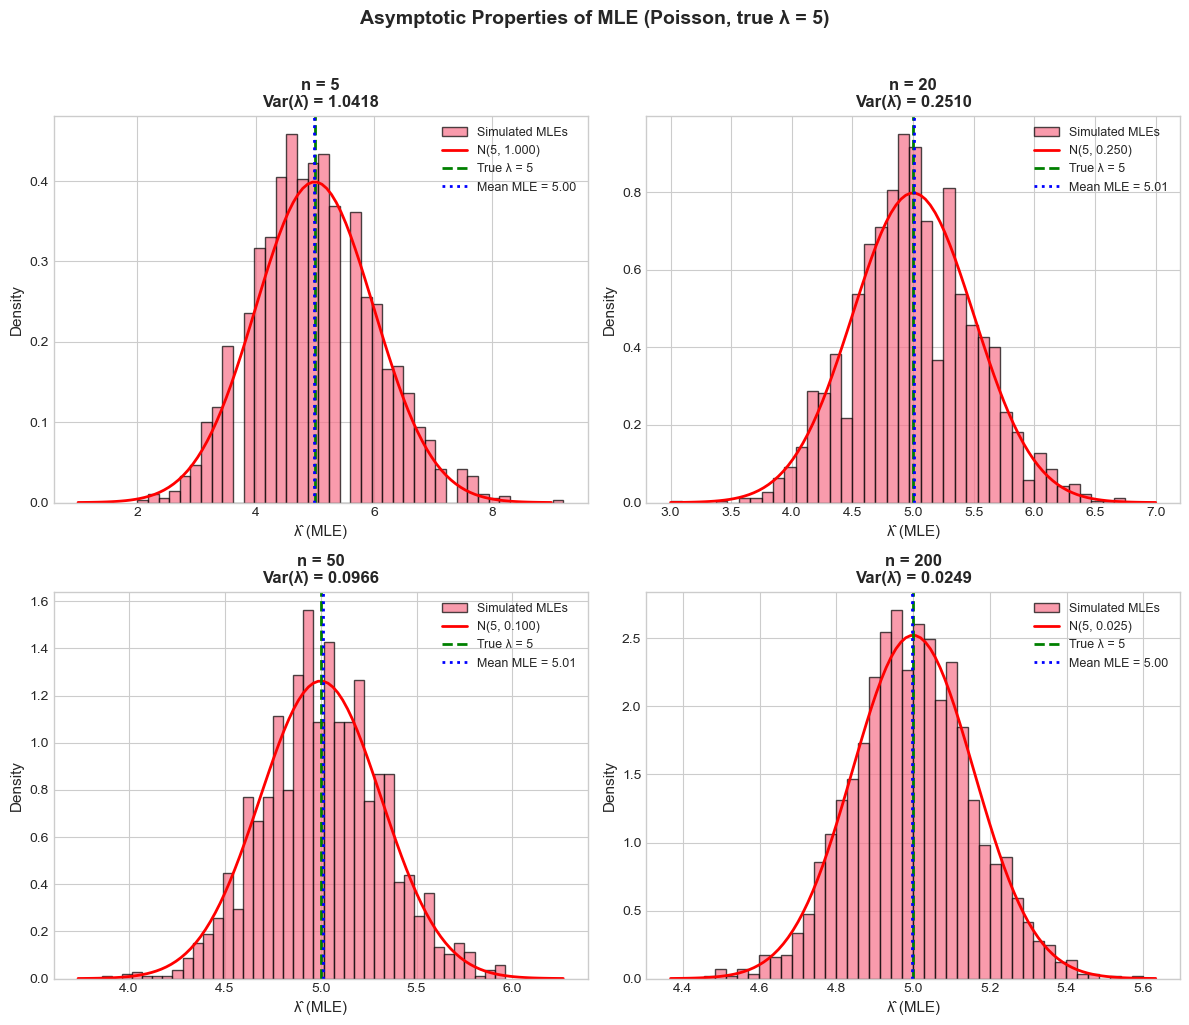


🔍 Observations
──────────────────────────────────────────────────
  • As n increases, the MLE distribution becomes more concentrated (consistency)
  • The distribution becomes approximately Normal (asymptotic normality)
  • Variance decreases as 1/n (efficiency)
  • The theoretical Normal approximation (red) matches simulations well for large n
──────────────────────────────────────────────────


In [8]:
def demonstrate_asymptotic_properties(true_lambda=5, n_simulations=2000):
    sample_sizes = [5, 20, 50, 200]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for idx, n in enumerate(sample_sizes):
        mle_estimates = []
        for _ in range(n_simulations):
            data = np.random.poisson(true_lambda, n)
            lambda_hat = np.mean(data)
            mle_estimates.append(lambda_hat)
        
        mle_estimates = np.array(mle_estimates)
        
        theoretical_std = np.sqrt(true_lambda / n)
        x_range = np.linspace(true_lambda - 4*theoretical_std, true_lambda + 4*theoretical_std, 100)
        theoretical_pdf = stats.norm.pdf(x_range, true_lambda, theoretical_std)
        
        ax = axes[idx]
        ax.hist(mle_estimates, bins=40, density=True, alpha=0.7, edgecolor='black', label='Simulated MLEs')
        ax.plot(x_range, theoretical_pdf, 'r-', linewidth=2, label=f'N({true_lambda}, {true_lambda/n:.3f})')
        ax.axvline(true_lambda, color='green', linestyle='--', linewidth=2, label=f'True λ = {true_lambda}')
        ax.axvline(np.mean(mle_estimates), color='blue', linestyle=':', linewidth=2, label=f'Mean MLE = {np.mean(mle_estimates):.2f}')
        
        ax.set_xlabel('λ̂ (MLE)', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'n = {n}\nVar(λ̂) = {np.var(mle_estimates):.4f}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
    
    plt.suptitle(f'Asymptotic Properties of MLE (Poisson, true λ = {true_lambda})', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print_box("Observations", [
        "As n increases, the MLE distribution becomes more concentrated (consistency)",
        "The distribution becomes approximately Normal (asymptotic normality)",
        "Variance decreases as 1/n (efficiency)",
        "The theoretical Normal approximation (red) matches simulations well for large n"
    ], "🔍")

demonstrate_asymptotic_properties()

### 🧠 Self-Check Question 2

If you double your sample size, what happens to the standard error of your MLE?

<details>
<summary>Click for answer</summary>

The standard error is proportional to $1/\sqrt{n}$.

If $n \to 2n$, then $\text{SE} \to \text{SE}/\sqrt{2} \approx 0.71 \cdot \text{SE}$

So doubling the sample size reduces the standard error by about 29%.
</details>

---

<a id='part3'></a>
# Part III: Distribution Toolkit with Full Derivations

In this section, we derive the MLE for common distributions step by step.

## 3.1 Bernoulli Distribution

**Use case:** Binary outcomes (success/failure, yes/no, 0/1)

### The Distribution

$$P(X = x | p) = p^x (1-p)^{1-x}, \quad x \in \{0, 1\}$$

### Step-by-Step MLE Derivation

**Given:** Data $x_1, x_2, \ldots, x_n$ where each $x_i \in \{0, 1\}$

**Step 1: Write the likelihood**
$$L(p) = \prod_{i=1}^{n} p^{x_i}(1-p)^{1-x_i} = p^{\sum x_i}(1-p)^{n - \sum x_i}$$

**Step 2: Take the log**
$$\ell(p) = \left(\sum_{i=1}^{n} x_i\right) \log p + \left(n - \sum_{i=1}^{n} x_i\right) \log(1-p)$$

Let $k = \sum_{i=1}^{n} x_i$ (number of successes). Then:
$$\ell(p) = k \log p + (n-k) \log(1-p)$$

**Step 3: Find the score (derivative)**
$$s(p) = \frac{d\ell}{dp} = \frac{k}{p} - \frac{n-k}{1-p}$$

**Step 4: Solve the score equation $s(p) = 0$**
$$\frac{k}{p} = \frac{n-k}{1-p}$$
$$k(1-p) = p(n-k)$$
$$k - kp = pn - pk$$
$$k = pn$$
$$\boxed{\hat{p}_{\text{ML}} = \frac{k}{n} = \bar{x}}$$

**Step 5: Verify it's a maximum (second derivative)**
$$\frac{d^2\ell}{dp^2} = -\frac{k}{p^2} - \frac{n-k}{(1-p)^2} < 0 \quad \checkmark$$

📧 Spam Email Classification Example
══════════════════════════════════════════════════
Data: [0 1 0 0 1 0 1 1 0 0 1 0 0 0 1 0 1 0 0 1]
Total emails: n = 20
Spam emails: k = 8

✓ MLE: p̂ = k/n = 8/20 = 0.400

Interpretation: 40.0% of emails are estimated to be spam


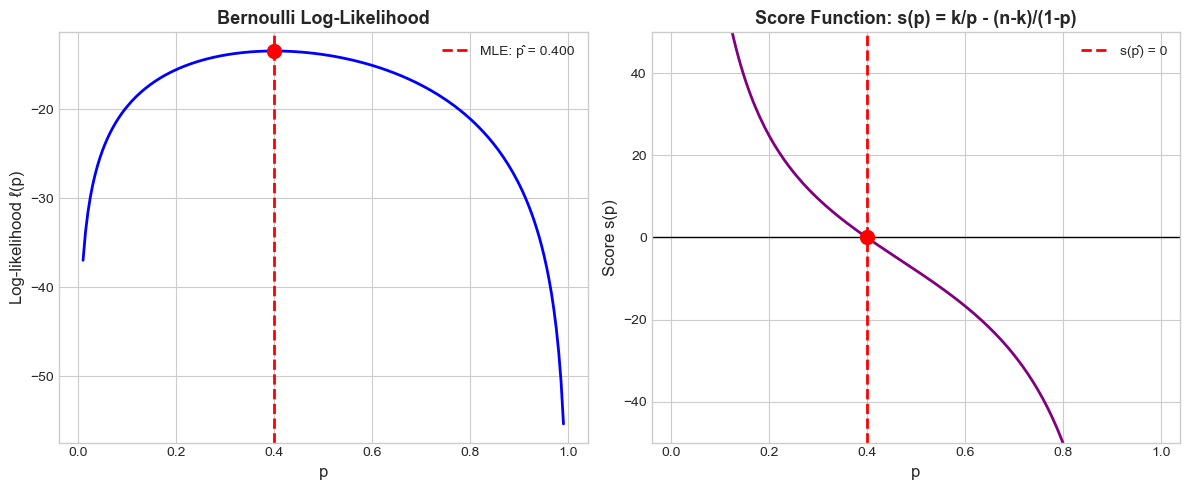

In [9]:
# Bernoulli MLE: Worked Example
emails = np.array([0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1])
n = len(emails)
k = np.sum(emails)

p_hat = k / n

print("📧 Spam Email Classification Example")
print("═" * 50)
print(f"Data: {emails}")
print(f"Total emails: n = {n}")
print(f"Spam emails: k = {k}")
print(f"\n✓ MLE: p̂ = k/n = {k}/{n} = {p_hat:.3f}")
print(f"\nInterpretation: {p_hat*100:.1f}% of emails are estimated to be spam")

# Visualize likelihood
p_range = np.linspace(0.01, 0.99, 200)
log_lik = k * np.log(p_range) + (n - k) * np.log(1 - p_range)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(p_range, log_lik, 'b-', linewidth=2)
ax1.axvline(p_hat, color='red', linestyle='--', linewidth=2, label=f'MLE: p̂ = {p_hat:.3f}')
ax1.plot(p_hat, k * np.log(p_hat) + (n - k) * np.log(1 - p_hat), 'ro', markersize=10)
ax1.set_xlabel('p', fontsize=12)
ax1.set_ylabel('Log-likelihood ℓ(p)', fontsize=12)
ax1.set_title('Bernoulli Log-Likelihood', fontsize=13, fontweight='bold')
ax1.legend()

score = k / p_range - (n - k) / (1 - p_range)
ax2.plot(p_range, score, 'purple', linewidth=2)
ax2.axhline(0, color='black', linewidth=1)
ax2.axvline(p_hat, color='red', linestyle='--', linewidth=2, label=f's(p̂) = 0')
ax2.plot(p_hat, 0, 'ro', markersize=10)
ax2.set_xlabel('p', fontsize=12)
ax2.set_ylabel('Score s(p)', fontsize=12)
ax2.set_title('Score Function: s(p) = k/p - (n-k)/(1-p)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.set_ylim([-50, 50])

plt.tight_layout()
plt.show()

---
## 3.3 Poisson Distribution

**Use case:** Count data (number of events in a fixed interval)

### The Distribution

$$P(X = k | \lambda) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0, 1, 2, \ldots$$

**Key property:** $E[X] = \text{Var}(X) = \lambda$

### Step-by-Step MLE Derivation

**Given:** Count data $x_1, x_2, \ldots, x_n$

**Step 1: Write the likelihood**
$$L(\lambda) = \prod_{i=1}^{n} \frac{\lambda^{x_i} e^{-\lambda}}{x_i!} = \frac{\lambda^{\sum x_i} e^{-n\lambda}}{\prod x_i!}$$

**Step 2: Take the log**
$$\ell(\lambda) = \left(\sum_{i=1}^{n} x_i\right) \log \lambda - n\lambda - \sum_{i=1}^{n} \log(x_i!)$$

**Step 3: Find the score**
$$s(\lambda) = \frac{d\ell}{d\lambda} = \frac{\sum x_i}{\lambda} - n$$

**Step 4: Solve $s(\lambda) = 0$**
$$\frac{\sum x_i}{\lambda} = n$$
$$\boxed{\hat{\lambda}_{\text{ML}} = \frac{1}{n}\sum_{i=1}^{n} x_i = \bar{x}}$$

**Step 5: Verify maximum**
$$\frac{d^2\ell}{d\lambda^2} = -\frac{\sum x_i}{\lambda^2} < 0 \quad \checkmark$$

📞 Call Center Example
══════════════════════════════════════════════════
Data (calls per hour): [ 8 12  5 10  7 11  9  6 13  8  7 10  4 12  9  8 11  6 10  7]
Number of observations: n = 20

Sample mean: 8.65
Sample variance: 6.13
Ratio (Var/Mean): 0.71

✓ Poisson appropriate

✓ MLE: λ̂ = x̄ = 8.65 calls/hour


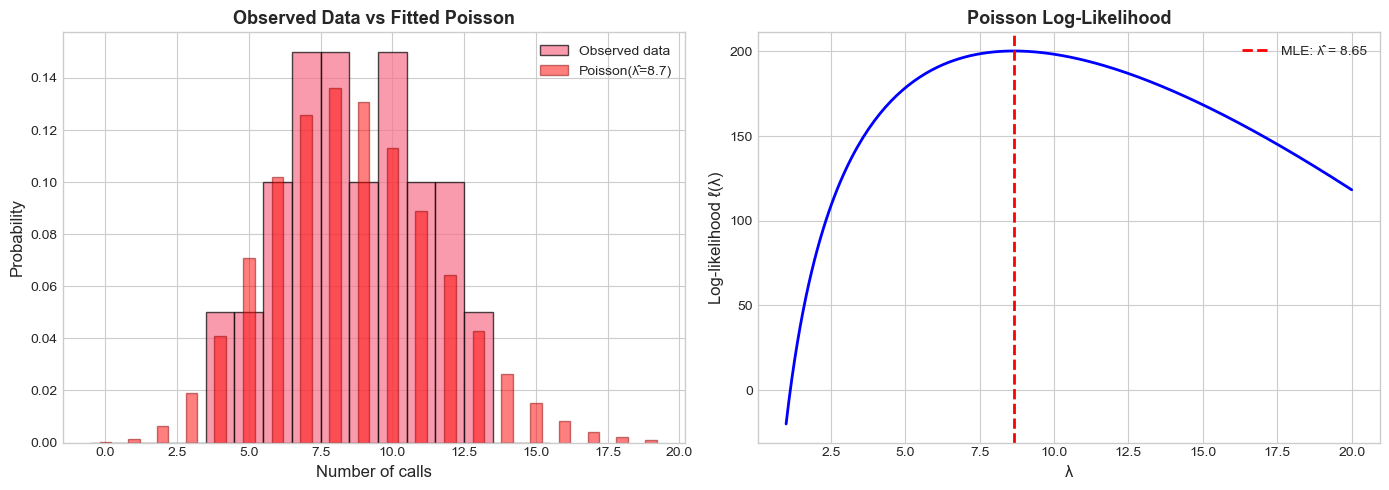


📊 Business Application:
   P(≥15 calls in an hour) = 0.0312 = 3.12%
   P(≤5 calls in an hour) = 0.1387 = 13.87%


In [10]:
# Poisson MLE: Call Center Example
calls_per_hour = np.array([8, 12, 5, 10, 7, 11, 9, 6, 13, 8, 7, 10, 4, 12, 9, 8, 11, 6, 10, 7])
n = len(calls_per_hour)

lambda_hat = np.mean(calls_per_hour)
sample_mean = np.mean(calls_per_hour)
sample_var = np.var(calls_per_hour, ddof=1)

print("📞 Call Center Example")
print("═" * 50)
print(f"Data (calls per hour): {calls_per_hour}")
print(f"Number of observations: n = {n}")
print(f"\nSample mean: {sample_mean:.2f}")
print(f"Sample variance: {sample_var:.2f}")
print(f"Ratio (Var/Mean): {sample_var/sample_mean:.2f}")
print(f"\n{'✓ Poisson appropriate' if 0.5 < sample_var/sample_mean < 2 else '⚠️ Poisson may not be appropriate'}")
print(f"\n✓ MLE: λ̂ = x̄ = {lambda_hat:.2f} calls/hour")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x_vals = np.arange(0, 20)
poisson_pmf = stats.poisson.pmf(x_vals, lambda_hat)

ax1.hist(calls_per_hour, bins=np.arange(-0.5, 16.5, 1), density=True, alpha=0.7, 
         edgecolor='black', label='Observed data')
ax1.bar(x_vals, poisson_pmf, alpha=0.5, color='red', edgecolor='darkred', 
        width=0.4, label=f'Poisson(λ̂={lambda_hat:.1f})')
ax1.set_xlabel('Number of calls', fontsize=12)
ax1.set_ylabel('Probability', fontsize=12)
ax1.set_title('Observed Data vs Fitted Poisson', fontsize=13, fontweight='bold')
ax1.legend()

lambda_range = np.linspace(1, 20, 200)
log_lik = np.sum(calls_per_hour) * np.log(lambda_range) - n * lambda_range

ax2.plot(lambda_range, log_lik, 'b-', linewidth=2)
ax2.axvline(lambda_hat, color='red', linestyle='--', linewidth=2, label=f'MLE: λ̂ = {lambda_hat:.2f}')
ax2.set_xlabel('λ', fontsize=12)
ax2.set_ylabel('Log-likelihood ℓ(λ)', fontsize=12)
ax2.set_title('Poisson Log-Likelihood', fontsize=13, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n📊 Business Application:")
print(f"   P(≥15 calls in an hour) = {1 - stats.poisson.cdf(14, lambda_hat):.4f} = {(1 - stats.poisson.cdf(14, lambda_hat))*100:.2f}%")
print(f"   P(≤5 calls in an hour) = {stats.poisson.cdf(5, lambda_hat):.4f} = {stats.poisson.cdf(5, lambda_hat)*100:.2f}%")

---
## 3.4 Exponential Distribution

**Use case:** Time between events, waiting times, component lifetimes

### The Distribution

$$f(x | \lambda) = \lambda e^{-\lambda x}, \quad x \geq 0$$

**Key properties:**
- $E[X] = 1/\lambda$ (Mean Time To Failure = MTTF)
- $\text{Var}(X) = 1/\lambda^2$
- Memoryless property: $P(X > s + t | X > s) = P(X > t)$

### Step-by-Step MLE Derivation

**Given:** Time data $x_1, x_2, \ldots, x_n > 0$

**Step 1: Write the likelihood**
$$L(\lambda) = \prod_{i=1}^{n} \lambda e^{-\lambda x_i} = \lambda^n e^{-\lambda \sum x_i}$$

**Step 2: Take the log**
$$\ell(\lambda) = n \log \lambda - \lambda \sum_{i=1}^{n} x_i$$

**Step 3: Find the score**
$$s(\lambda) = \frac{n}{\lambda} - \sum_{i=1}^{n} x_i$$

**Step 4: Solve $s(\lambda) = 0$**
$$\frac{n}{\lambda} = \sum x_i$$
$$\boxed{\hat{\lambda}_{\text{ML}} = \frac{n}{\sum x_i} = \frac{1}{\bar{x}}}$$

**Step 5: Verify maximum**
$$\frac{d^2\ell}{d\lambda^2} = -\frac{n}{\lambda^2} < 0 \quad \checkmark$$

### MLE for MTTF (using invariance property)

Since $\text{MTTF} = 1/\lambda$ and $\hat{\lambda}_{\text{ML}} = 1/\bar{x}$:

$$\boxed{\widehat{\text{MTTF}}_{\text{ML}} = \bar{x}}$$

🔧 Component Reliability Example
══════════════════════════════════════════════════
Failure times (hours): [145  89 203 167 112 178  95 156 134 189 201 142]
Number of components: n = 12

✓ MLE for rate: λ̂ = 1/x̄ = 0.006626 failures/hour
✓ MLE for MTTF: 150.9 hours


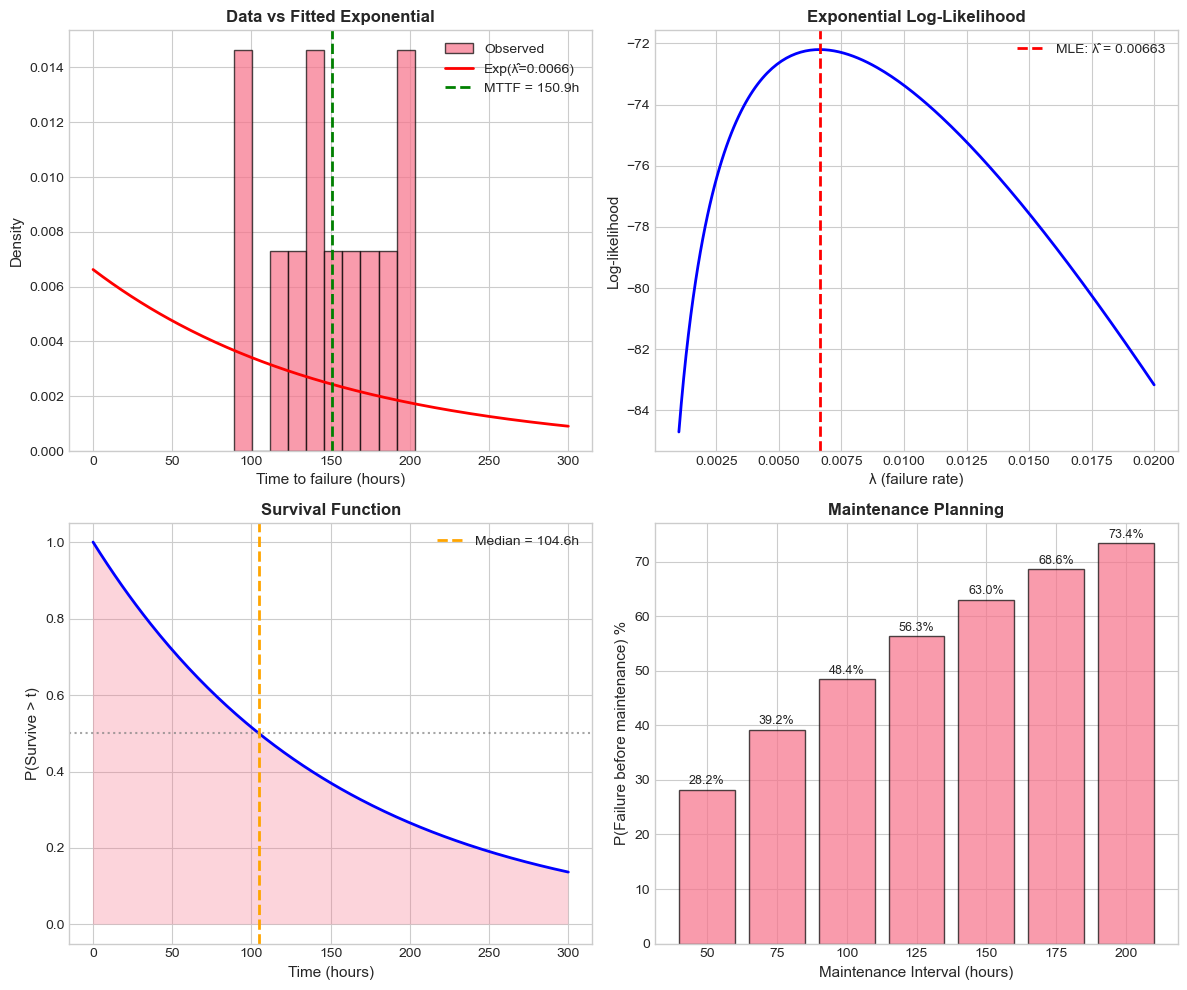


📊 Maintenance Planning Insights:
   Maintenance at 100h: P(failure) = 48.4%
   Maintenance at 125h: P(failure) = 56.3%
   Maintenance at 150h: P(failure) = 63.0%


In [11]:
# Exponential MLE: Component Reliability Example
failure_times = np.array([145, 89, 203, 167, 112, 178, 95, 156, 134, 189, 201, 142])
n = len(failure_times)

lambda_hat = 1 / np.mean(failure_times)
mttf_hat = np.mean(failure_times)

print("🔧 Component Reliability Example")
print("═" * 50)
print(f"Failure times (hours): {failure_times}")
print(f"Number of components: n = {n}")
print(f"\n✓ MLE for rate: λ̂ = 1/x̄ = {lambda_hat:.6f} failures/hour")
print(f"✓ MLE for MTTF: {mttf_hat:.1f} hours")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Data histogram vs fitted exponential
ax1 = axes[0, 0]
t_vals = np.linspace(0, 300, 200)
exp_pdf = stats.expon.pdf(t_vals, scale=mttf_hat)

ax1.hist(failure_times, bins=10, density=True, alpha=0.7, edgecolor='black', label='Observed')
ax1.plot(t_vals, exp_pdf, 'r-', linewidth=2, label=f'Exp(λ̂={lambda_hat:.4f})')
ax1.axvline(mttf_hat, color='green', linestyle='--', linewidth=2, label=f'MTTF = {mttf_hat:.1f}h')
ax1.set_xlabel('Time to failure (hours)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Data vs Fitted Exponential', fontsize=12, fontweight='bold')
ax1.legend()

# Log-likelihood
ax2 = axes[0, 1]
lambda_range = np.linspace(0.001, 0.02, 200)
log_lik = n * np.log(lambda_range) - lambda_range * np.sum(failure_times)

ax2.plot(lambda_range, log_lik, 'b-', linewidth=2)
ax2.axvline(lambda_hat, color='red', linestyle='--', linewidth=2, label=f'MLE: λ̂ = {lambda_hat:.5f}')
ax2.set_xlabel('λ (failure rate)', fontsize=11)
ax2.set_ylabel('Log-likelihood', fontsize=11)
ax2.set_title('Exponential Log-Likelihood', fontsize=12, fontweight='bold')
ax2.legend()

# Survival function
ax3 = axes[1, 0]
survival_prob = np.exp(-lambda_hat * t_vals)
ax3.plot(t_vals, survival_prob, 'b-', linewidth=2)
ax3.axhline(0.5, color='gray', linestyle=':', alpha=0.7)
ax3.axvline(mttf_hat * np.log(2), color='orange', linestyle='--', linewidth=2, 
           label=f'Median = {mttf_hat * np.log(2):.1f}h')
ax3.fill_between(t_vals, survival_prob, alpha=0.3)
ax3.set_xlabel('Time (hours)', fontsize=11)
ax3.set_ylabel('P(Survive > t)', fontsize=11)
ax3.set_title('Survival Function', fontsize=12, fontweight='bold')
ax3.legend()

# Maintenance planning
ax4 = axes[1, 1]
maintenance_times = np.array([50, 75, 100, 125, 150, 175, 200])
failure_probs = 1 - np.exp(-lambda_hat * maintenance_times)

bars = ax4.bar(maintenance_times, failure_probs * 100, width=20, alpha=0.7, edgecolor='black')
ax4.set_xlabel('Maintenance Interval (hours)', fontsize=11)
ax4.set_ylabel('P(Failure before maintenance) %', fontsize=11)
ax4.set_title('Maintenance Planning', fontsize=12, fontweight='bold')

for bar, prob in zip(bars, failure_probs):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{prob*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Maintenance Planning Insights:")
for t in [100, 125, 150]:
    prob_fail = 1 - np.exp(-lambda_hat * t)
    print(f"   Maintenance at {t}h: P(failure) = {prob_fail*100:.1f}%")

---
## 3.5 Normal Distribution

**Use case:** Continuous measurements, errors, natural phenomena

### The Distribution

$$f(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

### Step-by-Step MLE Derivation

**Given:** Data $x_1, x_2, \ldots, x_n$

**Step 1: Write the likelihood**
$$L(\mu, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)$$

**Step 2: Take the log**
$$\ell(\mu, \sigma^2) = -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i - \mu)^2$$

**Step 3a: Find MLE for $\mu$**
$$\frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i - \mu) = 0$$
$$\sum_{i=1}^{n}(x_i - \mu) = 0$$
$$\boxed{\hat{\mu}_{\text{ML}} = \frac{1}{n}\sum_{i=1}^{n}x_i = \bar{x}}$$

**Step 3b: Find MLE for $\sigma^2$**
$$\frac{\partial \ell}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i - \mu)^2 = 0$$

Substituting $\hat{\mu} = \bar{x}$:
$$\boxed{\hat{\sigma}^2_{\text{ML}} = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

### ⚠️ Important: MLE for Variance is Biased!

$$E[\hat{\sigma}^2_{\text{ML}}] = \frac{n-1}{n}\sigma^2 \neq \sigma^2$$

The MLE **underestimates** the true variance. The unbiased estimator divides by $(n-1)$:
$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

📊 Normal Distribution MLE
══════════════════════════════════════════════════
True parameters: μ = 100, σ² = 225
Sample size: n = 50

✓ MLE for μ: μ̂ = 96.62
✓ MLE for σ²: σ̂²_ML = 192.22 (divides by n)
  Unbiased est: s² = 196.14 (divides by n-1)

⚠️  Bias of MLE: E[σ̂²_ML] = 0.9800 × σ² (underestimates by 2.0%)


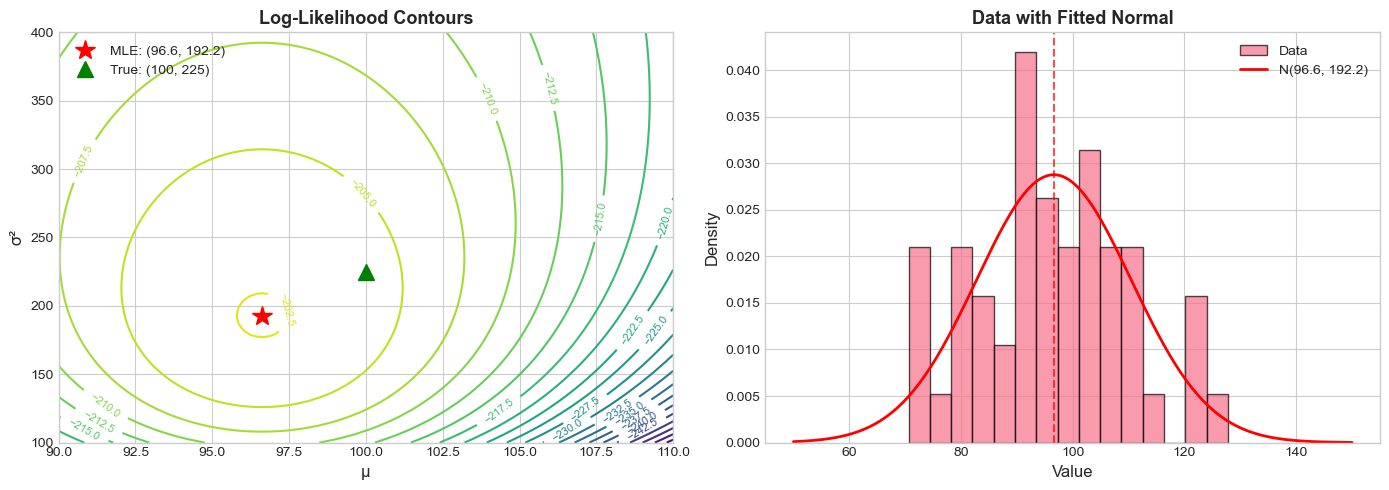

In [12]:
# Normal Distribution MLE
np.random.seed(42)
true_mu = 100
true_sigma = 15
n = 50
data = np.random.normal(true_mu, true_sigma, n)

mu_mle = np.mean(data)
sigma2_mle = np.mean((data - mu_mle)**2)
sigma2_unbiased = np.var(data, ddof=1)

print("📊 Normal Distribution MLE")
print("═" * 50)
print(f"True parameters: μ = {true_mu}, σ² = {true_sigma**2}")
print(f"Sample size: n = {n}")
print(f"\n✓ MLE for μ: μ̂ = {mu_mle:.2f}")
print(f"✓ MLE for σ²: σ̂²_ML = {sigma2_mle:.2f} (divides by n)")
print(f"  Unbiased est: s² = {sigma2_unbiased:.2f} (divides by n-1)")
print(f"\n⚠️  Bias of MLE: E[σ̂²_ML] = {(n-1)/n:.4f} × σ² (underestimates by {100*(1-(n-1)/n):.1f}%)")

# Visualize the 2D log-likelihood surface
mu_range = np.linspace(90, 110, 100)
sigma2_range = np.linspace(100, 400, 100)
MU, SIGMA2 = np.meshgrid(mu_range, sigma2_range)

def log_likelihood_normal(mu, sigma2, data):
    n = len(data)
    return -n/2 * np.log(2*np.pi*sigma2) - np.sum((data - mu)**2) / (2*sigma2)

Z = np.zeros_like(MU)
for i in range(len(sigma2_range)):
    for j in range(len(mu_range)):
        Z[i, j] = log_likelihood_normal(MU[i, j], SIGMA2[i, j], data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

contour = ax1.contour(MU, SIGMA2, Z, levels=20, cmap='viridis')
ax1.clabel(contour, inline=True, fontsize=8)
ax1.plot(mu_mle, sigma2_mle, 'r*', markersize=15, label=f'MLE: ({mu_mle:.1f}, {sigma2_mle:.1f})')
ax1.plot(true_mu, true_sigma**2, 'g^', markersize=12, label=f'True: ({true_mu}, {true_sigma**2})')
ax1.set_xlabel('μ', fontsize=12)
ax1.set_ylabel('σ²', fontsize=12)
ax1.set_title('Log-Likelihood Contours', fontsize=13, fontweight='bold')
ax1.legend()

x_plot = np.linspace(50, 150, 200)
fitted_pdf = stats.norm.pdf(x_plot, mu_mle, np.sqrt(sigma2_mle))

ax2.hist(data, bins=15, density=True, alpha=0.7, edgecolor='black', label='Data')
ax2.plot(x_plot, fitted_pdf, 'r-', linewidth=2, label=f'N({mu_mle:.1f}, {sigma2_mle:.1f})')
ax2.axvline(mu_mle, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Value', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Data with Fitted Normal', fontsize=13, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 3.6 Distribution Selection Guide

Choosing the right distribution is **critical** for MLE to work well.

### Decision Tree

```
What type of data do you have?
│
├── Binary (0/1, yes/no, success/fail)
│   └── → Bernoulli
│
├── Counts (0, 1, 2, 3, ...)
│   ├── Fixed number of trials? → Binomial
│   ├── Events in fixed interval? → Poisson
│   └── Variance >> Mean? → Negative Binomial
│
├── Continuous, positive
│   ├── Time to event/failure? → Exponential or Weibull
│   ├── Right-skewed? → Log-normal or Gamma
│   └── Bounded [0,1]? → Beta
│
└── Continuous, unbounded
    ├── Symmetric, light tails? → Normal
    └── Heavy tails/outliers? → t-distribution or Laplace
```

### Quick Reference Table

| Distribution | Data Type | MLE | Key Check |
|-------------|-----------|-----|----------|
| Bernoulli | Binary | $\hat{p} = \bar{x}$ | - |
| Binomial | Count (fixed n) | $\hat{p} = k/n$ | $k \leq n$ |
| Poisson | Count | $\hat{\lambda} = \bar{x}$ | Var ≈ Mean |
| Exponential | Time > 0 | $\hat{\lambda} = 1/\bar{x}$ | Memoryless |
| Normal | Continuous | $\hat{\mu} = \bar{x}$, $\hat{\sigma}^2 = \frac{1}{n}\sum(x_i-\bar{x})^2$ | Symmetric, no outliers |

In [13]:
# Distribution Selection Helper
def check_poisson_appropriateness(data):
    mean = np.mean(data)
    var = np.var(data, ddof=1)
    ratio = var / mean
    
    print("\n📊 Poisson Appropriateness Check")
    print("─" * 40)
    print(f"Sample mean: {mean:.3f}")
    print(f"Sample variance: {var:.3f}")
    print(f"Variance/Mean ratio: {ratio:.3f}")
    print("─" * 40)
    
    if 0.7 < ratio < 1.3:
        print("✅ Poisson is APPROPRIATE (ratio ≈ 1)")
        return True
    elif ratio > 1.3:
        print("⚠️  OVERDISPERSION detected (Var > Mean)")
        print("   Consider: Negative Binomial distribution")
        return False
    else:
        print("⚠️  UNDERDISPERSION detected (Var < Mean)")
        print("   Consider: Binomial or other distribution")
        return False

print("Example 1: Good Poisson Data")
poisson_data = np.random.poisson(5, 100)
check_poisson_appropriateness(poisson_data)

print("\n" + "="*50)
print("Example 2: Overdispersed Data")
overdispersed = np.random.negative_binomial(3, 0.3, 100)
check_poisson_appropriateness(overdispersed)

Example 1: Good Poisson Data

📊 Poisson Appropriateness Check
────────────────────────────────────────
Sample mean: 4.860
Sample variance: 5.839
Variance/Mean ratio: 1.201
────────────────────────────────────────
✅ Poisson is APPROPRIATE (ratio ≈ 1)

Example 2: Overdispersed Data

📊 Poisson Appropriateness Check
────────────────────────────────────────
Sample mean: 7.720
Sample variance: 25.254
Variance/Mean ratio: 3.271
────────────────────────────────────────
⚠️  OVERDISPERSION detected (Var > Mean)
   Consider: Negative Binomial distribution


False

---
<a id='part4'></a>
# Part IV: MLE Properties

## 4.1 Bias of MLEs

An estimator $\hat{\theta}$ is **unbiased** if $E[\hat{\theta}] = \theta$.

**Important:** MLEs are **not always unbiased!**

### Example: Normal Variance MLE is Biased

$$E[\hat{\sigma}^2_{\text{ML}}] = E\left[\frac{1}{n}\sum_{i=1}^{n}(X_i - \bar{X})^2\right] = \frac{n-1}{n}\sigma^2$$

The MLE systematically **underestimates** the true variance.

### Why Use MLE Despite Bias?

1. **Bias decreases** as $n \to \infty$ (asymptotically unbiased)
2. **Mean Squared Error** may still be lower than unbiased alternatives
3. **Consistency**: MLE converges to true value
4. **Invariance**: Easy to get MLEs for transformed parameters

📊 Bias Comparison: MLE vs Unbiased Estimator
True variance: σ² = 25
══════════════════════════════════════════════════════════════════════
     n |    E[σ̂²_ML] |   Bias (MLE) |        E[s²] |   Bias (unb)
──────────────────────────────────────────────────────────────────────
     5 |       20.197 |       -4.803 |       25.247 |        0.247
    10 |       22.495 |       -2.505 |       24.994 |       -0.006
    20 |       23.757 |       -1.243 |       25.007 |        0.007
    50 |       24.541 |       -0.459 |       25.042 |        0.042
   100 |       24.698 |       -0.302 |       24.948 |       -0.052
   200 |       24.852 |       -0.148 |       24.977 |       -0.023


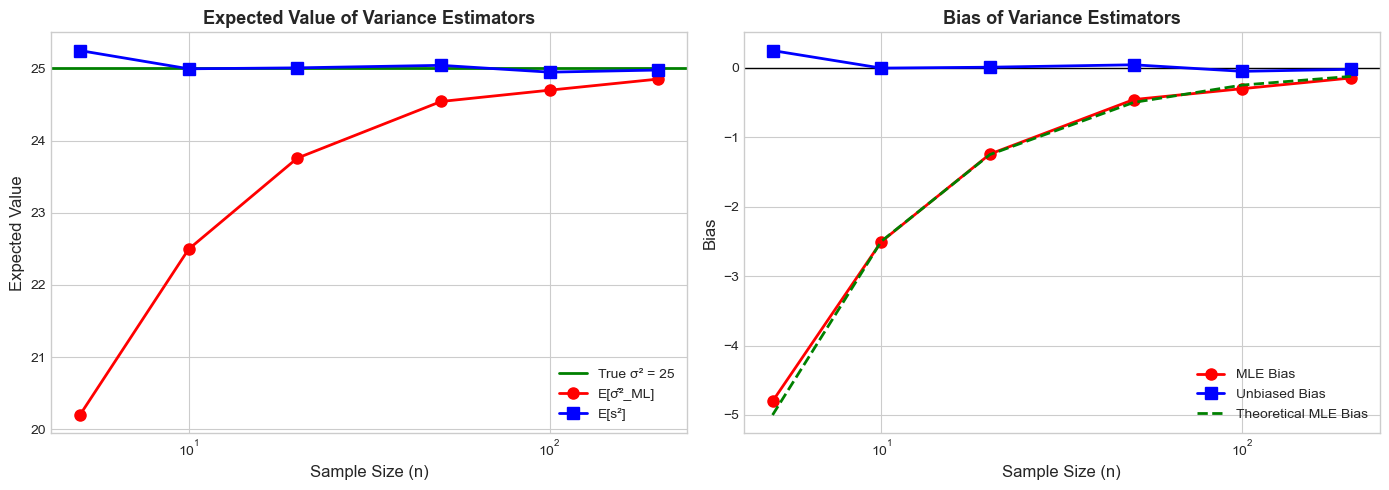


🎯 Key Observations
──────────────────────────────────────────────────
  • MLE systematically underestimates variance (negative bias)
  • Bias = -σ²/n → decreases as n increases
  • Unbiased estimator (dividing by n-1) has ~zero bias
  • For large n, the difference is negligible
──────────────────────────────────────────────────


In [14]:
# Demonstrate Bias of Normal Variance MLE
def simulate_variance_bias(true_sigma2, sample_sizes, n_simulations=5000):
    results = {'n': [], 'MLE_mean': [], 'Unbiased_mean': [], 
               'MLE_bias': [], 'Unbiased_bias': [], 'theoretical_bias': []}
    
    for n in sample_sizes:
        mle_estimates = []
        unbiased_estimates = []
        
        for _ in range(n_simulations):
            data = np.random.normal(0, np.sqrt(true_sigma2), n)
            sigma2_mle = np.mean((data - np.mean(data))**2)
            sigma2_unbiased = np.var(data, ddof=1)
            mle_estimates.append(sigma2_mle)
            unbiased_estimates.append(sigma2_unbiased)
        
        results['n'].append(n)
        results['MLE_mean'].append(np.mean(mle_estimates))
        results['Unbiased_mean'].append(np.mean(unbiased_estimates))
        results['MLE_bias'].append(np.mean(mle_estimates) - true_sigma2)
        results['Unbiased_bias'].append(np.mean(unbiased_estimates) - true_sigma2)
        results['theoretical_bias'].append((n-1)/n * true_sigma2 - true_sigma2)
    
    return results

true_sigma2 = 25
sample_sizes = [5, 10, 20, 50, 100, 200]
results = simulate_variance_bias(true_sigma2, sample_sizes)

print("📊 Bias Comparison: MLE vs Unbiased Estimator")
print(f"True variance: σ² = {true_sigma2}")
print("═" * 70)
print(f"{'n':>6} | {'E[σ̂²_ML]':>12} | {'Bias (MLE)':>12} | {'E[s²]':>12} | {'Bias (unb)':>12}")
print("─" * 70)
for i in range(len(sample_sizes)):
    print(f"{results['n'][i]:>6} | {results['MLE_mean'][i]:>12.3f} | {results['MLE_bias'][i]:>12.3f} | "
          f"{results['Unbiased_mean'][i]:>12.3f} | {results['Unbiased_bias'][i]:>12.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.axhline(true_sigma2, color='green', linestyle='-', linewidth=2, label=f'True σ² = {true_sigma2}')
ax1.plot(results['n'], results['MLE_mean'], 'ro-', linewidth=2, markersize=8, label='E[σ̂²_ML]')
ax1.plot(results['n'], results['Unbiased_mean'], 'bs-', linewidth=2, markersize=8, label='E[s²]')
ax1.set_xlabel('Sample Size (n)', fontsize=12)
ax1.set_ylabel('Expected Value', fontsize=12)
ax1.set_title('Expected Value of Variance Estimators', fontsize=13, fontweight='bold')
ax1.legend()
ax1.set_xscale('log')

ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.plot(results['n'], results['MLE_bias'], 'ro-', linewidth=2, markersize=8, label='MLE Bias')
ax2.plot(results['n'], results['Unbiased_bias'], 'bs-', linewidth=2, markersize=8, label='Unbiased Bias')
ax2.plot(results['n'], results['theoretical_bias'], 'g--', linewidth=2, label='Theoretical MLE Bias')
ax2.set_xlabel('Sample Size (n)', fontsize=12)
ax2.set_ylabel('Bias', fontsize=12)
ax2.set_title('Bias of Variance Estimators', fontsize=13, fontweight='bold')
ax2.legend()
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

print_box("Key Observations", [
    "MLE systematically underestimates variance (negative bias)",
    "Bias = -σ²/n → decreases as n increases",
    "Unbiased estimator (dividing by n-1) has ~zero bias",
    "For large n, the difference is negligible"
], "🎯")

---
## 4.2 Invariance Property

### Theorem (Invariance of MLE)

If $\hat{\theta}_{\text{ML}}$ is the MLE of $\theta$, then for any function $g(\cdot)$:

$$\boxed{g(\hat{\theta}_{\text{ML}}) \text{ is the MLE of } g(\theta)}$$

### Why This is Powerful

You don't need to re-derive the MLE for transformed parameters!

### Examples

1. **Exponential MTTF:**
   - MLE of rate: $\hat{\lambda}_{\text{ML}} = 1/\bar{x}$
   - MLE of MTTF = $1/\lambda$: $\widehat{\text{MTTF}} = 1/\hat{\lambda} = \bar{x}$ ✓

2. **Normal standard deviation:**
   - MLE of variance: $\hat{\sigma}^2_{\text{ML}} = \frac{1}{n}\sum(x_i - \bar{x})^2$
   - MLE of σ: $\hat{\sigma}_{\text{ML}} = \sqrt{\hat{\sigma}^2_{\text{ML}}}$ ✓

3. **Bernoulli odds:**
   - MLE of $p$: $\hat{p} = k/n$
   - MLE of odds = $p/(1-p)$: $\widehat{\text{odds}} = \hat{p}/(1-\hat{p})$ ✓

In [15]:
# Demonstrate Invariance Property
print("🔄 Invariance Property Demonstration")
print("═" * 60)

# Example 1: Exponential MTTF
print("\n📌 Example 1: Exponential Distribution")
failure_times = np.array([145, 89, 203, 167, 112, 178, 95, 156, 134, 189])

lambda_mle = 1 / np.mean(failure_times)
mttf_mle = 1 / lambda_mle
mttf_direct = np.mean(failure_times)

print(f"   Data: {failure_times}")
print(f"   MLE of λ: λ̂ = {lambda_mle:.6f}")
print(f"   MLE of MTTF (via invariance): 1/λ̂ = {mttf_mle:.2f}")
print(f"   Direct calculation: x̄ = {mttf_direct:.2f}")
print(f"   ✓ They match!")

# Example 2: Bernoulli odds
print("\n📌 Example 2: Bernoulli Odds")
successes = 35
trials = 100

p_mle = successes / trials
odds_mle = p_mle / (1 - p_mle)

print(f"   Successes: {successes}, Trials: {trials}")
print(f"   MLE of p: p̂ = {p_mle:.3f}")
print(f"   MLE of odds (via invariance): p̂/(1-p̂) = {odds_mle:.4f}")
print(f"   Interpretation: {odds_mle:.2f} to 1 odds of success")

# Example 3: Normal coefficient of variation
print("\n📌 Example 3: Coefficient of Variation (CV)")
data = np.array([23, 25, 21, 27, 22, 24, 26, 23, 25, 24])

mu_mle = np.mean(data)
sigma_mle = np.sqrt(np.mean((data - mu_mle)**2))
cv_mle = sigma_mle / mu_mle

print(f"   Data: {data}")
print(f"   MLE of μ: {mu_mle:.2f}")
print(f"   MLE of σ: {sigma_mle:.2f}")
print(f"   MLE of CV (via invariance): σ̂/μ̂ = {cv_mle:.4f} = {cv_mle*100:.2f}%")

🔄 Invariance Property Demonstration
════════════════════════════════════════════════════════════

📌 Example 1: Exponential Distribution
   Data: [145  89 203 167 112 178  95 156 134 189]
   MLE of λ: λ̂ = 0.006812
   MLE of MTTF (via invariance): 1/λ̂ = 146.80
   Direct calculation: x̄ = 146.80
   ✓ They match!

📌 Example 2: Bernoulli Odds
   Successes: 35, Trials: 100
   MLE of p: p̂ = 0.350
   MLE of odds (via invariance): p̂/(1-p̂) = 0.5385
   Interpretation: 0.54 to 1 odds of success

📌 Example 3: Coefficient of Variation (CV)
   Data: [23 25 21 27 22 24 26 23 25 24]
   MLE of μ: 24.00
   MLE of σ: 1.73
   MLE of CV (via invariance): σ̂/μ̂ = 0.0722 = 7.22%


---
<a id='part5'></a>
# Part V: The ML = LS Connection

## When Does Maximum Likelihood Equal Least Squares?

### The Big Theorem

> **Under Gaussian noise, Maximum Likelihood = Least Squares**

### Setup: Linear Regression

Model: $y_i = \mathbf{x}_i^T \boldsymbol{\theta} + \varepsilon_i$, where $\varepsilon_i \stackrel{\text{iid}}{\sim} N(0, \sigma^2)$

### Least Squares Objective

$$\hat{\boldsymbol{\theta}}_{\text{LS}} = \arg\min_{\boldsymbol{\theta}} \sum_{i=1}^{n}(y_i - \mathbf{x}_i^T\boldsymbol{\theta})^2$$

### Maximum Likelihood Derivation

Since $y_i | \mathbf{x}_i \sim N(\mathbf{x}_i^T\boldsymbol{\theta}, \sigma^2)$:

$$L(\boldsymbol{\theta}, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - \mathbf{x}_i^T\boldsymbol{\theta})^2}{2\sigma^2}\right)$$

$$\ell(\boldsymbol{\theta}, \sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - \mathbf{x}_i^T\boldsymbol{\theta})^2$$

Maximizing $\ell$ with respect to $\boldsymbol{\theta}$ is equivalent to:

$$\max_{\boldsymbol{\theta}} \ell \Leftrightarrow \min_{\boldsymbol{\theta}} \sum_{i=1}^{n}(y_i - \mathbf{x}_i^T\boldsymbol{\theta})^2$$

### Therefore:

$$\boxed{\hat{\boldsymbol{\theta}}_{\text{ML}} = \hat{\boldsymbol{\theta}}_{\text{LS}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}}$$

📈 Linear Regression: ML = LS Demonstration
════════════════════════════════════════════════════════════
True model: y = 2.0 + 3.0x + ε, where ε ~ N(0, 1.5²)
Sample size: n = 50

────────────────────────────────────────────────────────────
Method               | θ₀ (intercept)  | θ₁ (slope)     
────────────────────────────────────────────────────────────
True................ | 2.0000          | 3.0000         
Least Squares....... | 2.1450          | 2.9665         
Maximum Likelihood.. | 2.1450          | 2.9665         
────────────────────────────────────────────────────────────
Difference: |θ_LS - θ_ML| = [0.000002, 0.000001]

✓ ML and LS give the SAME estimates!


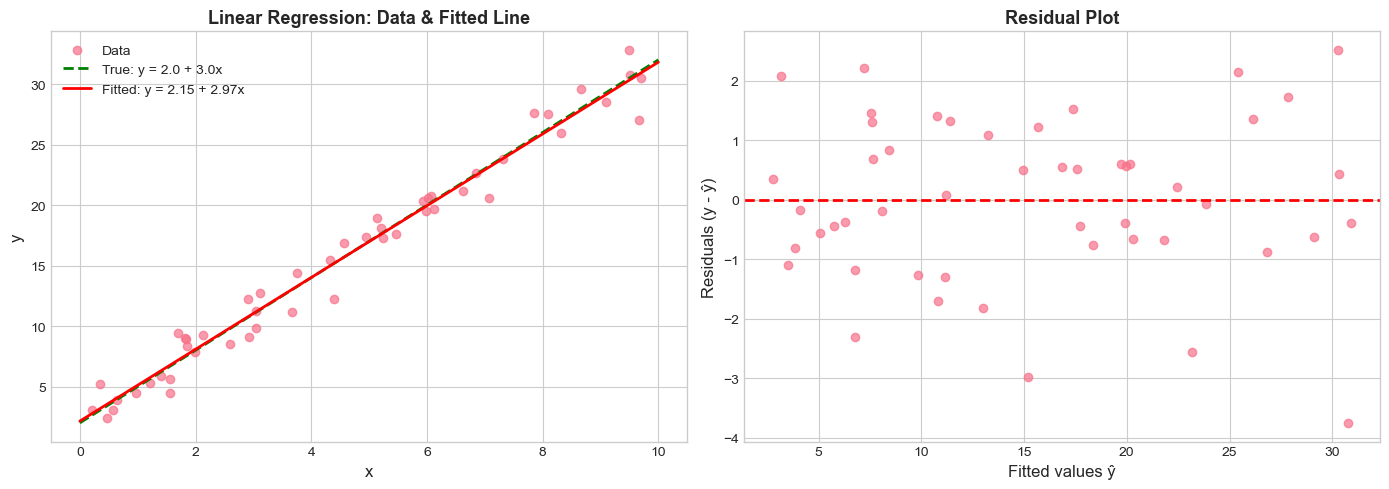


📊 ML Bonus - Noise estimate:
   True σ: 1.5
   ML σ̂: 1.361


In [16]:
# Demonstrate ML = LS for Linear Regression
np.random.seed(42)

n_samples = 50
true_theta = np.array([2.0, 3.0])
true_sigma = 1.5

x = np.random.uniform(0, 10, n_samples)
X = np.column_stack([np.ones(n_samples), x])
y_true = X @ true_theta
noise = np.random.normal(0, true_sigma, n_samples)
y = y_true + noise

print("📈 Linear Regression: ML = LS Demonstration")
print("═" * 60)
print(f"True model: y = {true_theta[0]} + {true_theta[1]}x + ε, where ε ~ N(0, {true_sigma}²)")
print(f"Sample size: n = {n_samples}")

# Method 1: Least Squares
theta_ls = np.linalg.inv(X.T @ X) @ X.T @ y

# Method 2: Maximum Likelihood
def neg_log_likelihood(params, X, y):
    theta = params[:-1]
    sigma2 = params[-1]**2
    n = len(y)
    residuals = y - X @ theta
    return n/2 * np.log(2*np.pi*sigma2) + np.sum(residuals**2) / (2*sigma2)

init_params = np.array([0, 0, 1])
result = minimize(neg_log_likelihood, init_params, args=(X, y), method='Nelder-Mead')
theta_ml = result.x[:-1]
sigma_ml = abs(result.x[-1])

print("\n" + "─" * 60)
print(f"{'Method':<20} | {'θ₀ (intercept)':<15} | {'θ₁ (slope)':<15}")
print("─" * 60)
print(f"{'True':.<20} | {true_theta[0]:<15.4f} | {true_theta[1]:<15.4f}")
print(f"{'Least Squares':.<20} | {theta_ls[0]:<15.4f} | {theta_ls[1]:<15.4f}")
print(f"{'Maximum Likelihood':.<20} | {theta_ml[0]:<15.4f} | {theta_ml[1]:<15.4f}")
print("─" * 60)
print(f"Difference: |θ_LS - θ_ML| = [{abs(theta_ls[0]-theta_ml[0]):.6f}, {abs(theta_ls[1]-theta_ml[1]):.6f}]")
print(f"\n✓ ML and LS give the SAME estimates!")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(x, y, alpha=0.7, label='Data')
x_line = np.linspace(0, 10, 100)
y_line_true = true_theta[0] + true_theta[1] * x_line
y_line_fit = theta_ls[0] + theta_ls[1] * x_line

ax1.plot(x_line, y_line_true, 'g--', linewidth=2, label=f'True: y = {true_theta[0]} + {true_theta[1]}x')
ax1.plot(x_line, y_line_fit, 'r-', linewidth=2, label=f'Fitted: y = {theta_ls[0]:.2f} + {theta_ls[1]:.2f}x')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Linear Regression: Data & Fitted Line', fontsize=13, fontweight='bold')
ax1.legend()

residuals = y - X @ theta_ls
ax2.scatter(X @ theta_ls, residuals, alpha=0.7)
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Fitted values ŷ', fontsize=12)
ax2.set_ylabel('Residuals (y - ŷ)', fontsize=12)
ax2.set_title('Residual Plot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 ML Bonus - Noise estimate:")
print(f"   True σ: {true_sigma}")
print(f"   ML σ̂: {sigma_ml:.3f}")

---
<a id='part6'></a>
# Part VI: Real-World Applications

## 6.1 A/B Testing

**Scenario:** An e-commerce company tests two website designs.

🔬 A/B Testing Analysis
════════════════════════════════════════════════════════════

Design A: 175/2500 conversions
   MLE: p̂_A = 0.0700 (7.00%)
   95% CI: [6.00%, 8.00%]

Design B: 212/2500 conversions
   MLE: p̂_B = 0.0848 (8.48%)
   95% CI: [7.39%, 9.57%]

────────────────────────────────────────────────────────────
Difference: p̂_B - p̂_A = 1.48 percentage points
Relative lift: 21.1%

────────────────────────────────────────────────────────────
Hypothesis Test (H₀: p_A = p_B)
   z-statistic: 1.958
   p-value: 0.0502
   ❌ Not significant

────────────────────────────────────────────────────────────
📈 Business Impact (if implementing B):
   Additional conversions/month: 1480
   Additional revenue/month: $125,800


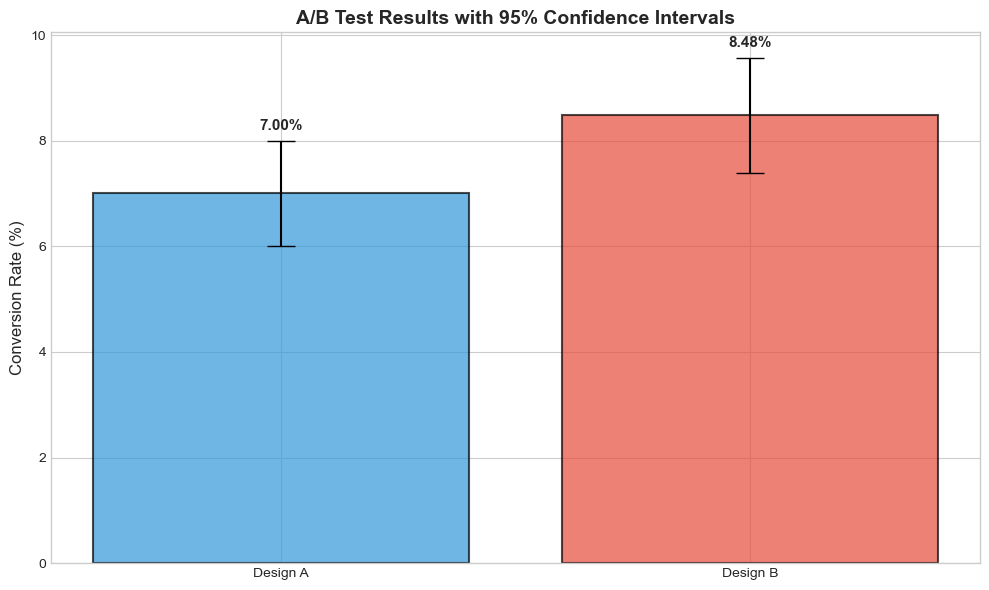

In [17]:
# A/B Testing Example
n_A, conversions_A = 2500, 175
n_B, conversions_B = 2500, 212

p_A = conversions_A / n_A
p_B = conversions_B / n_B

se_A = np.sqrt(p_A * (1 - p_A) / n_A)
se_B = np.sqrt(p_B * (1 - p_B) / n_B)

ci_A = (p_A - 1.96*se_A, p_A + 1.96*se_A)
ci_B = (p_B - 1.96*se_B, p_B + 1.96*se_B)

p_pooled = (conversions_A + conversions_B) / (n_A + n_B)
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_A + 1/n_B))
z_stat = (p_B - p_A) / se_pooled
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("🔬 A/B Testing Analysis")
print("═" * 60)
print(f"\nDesign A: {conversions_A}/{n_A} conversions")
print(f"   MLE: p̂_A = {p_A:.4f} ({p_A*100:.2f}%)")
print(f"   95% CI: [{ci_A[0]*100:.2f}%, {ci_A[1]*100:.2f}%]")

print(f"\nDesign B: {conversions_B}/{n_B} conversions")
print(f"   MLE: p̂_B = {p_B:.4f} ({p_B*100:.2f}%)")
print(f"   95% CI: [{ci_B[0]*100:.2f}%, {ci_B[1]*100:.2f}%]")

print(f"\n" + "─" * 60)
print(f"Difference: p̂_B - p̂_A = {(p_B - p_A)*100:.2f} percentage points")
print(f"Relative lift: {(p_B - p_A)/p_A*100:.1f}%")

print(f"\n" + "─" * 60)
print(f"Hypothesis Test (H₀: p_A = p_B)")
print(f"   z-statistic: {z_stat:.3f}")
print(f"   p-value: {p_value:.4f}")
print(f"   {'✅ Significant at α=0.05' if p_value < 0.05 else '❌ Not significant'}")

avg_order = 85
monthly_visitors = 100000
additional_revenue = (p_B - p_A) * monthly_visitors * avg_order

print(f"\n" + "─" * 60)
print(f"📈 Business Impact (if implementing B):")
print(f"   Additional conversions/month: {(p_B - p_A) * monthly_visitors:.0f}")
print(f"   Additional revenue/month: ${additional_revenue:,.0f}")

fig, ax = plt.subplots(figsize=(10, 6))
designs = ['Design A', 'Design B']
rates = [p_A * 100, p_B * 100]
errors = [1.96 * se_A * 100, 1.96 * se_B * 100]
colors = ['#3498db', '#e74c3c']

bars = ax.bar(designs, rates, yerr=errors, capsize=10, color=colors, 
              alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('A/B Test Results with 95% Confidence Intervals', fontsize=14, fontweight='bold')

for bar, rate, err in zip(bars, rates, errors):
    ax.text(bar.get_x() + bar.get_width()/2, rate + err + 0.2, 
            f'{rate:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
<a id='part7'></a>
# Part VII: When MLE Fails

MLE is powerful but not perfect. Here are situations where it can fail:

## 7.1 Wrong Distributional Assumption

**Problem:** If the assumed distribution doesn't match reality, MLE estimates can be misleading.

**Example:** Fitting Normal to heavy-tailed data

⚠️ MLE Failure: Heavy-Tailed Data
══════════════════════════════════════════════════
Data: [ 1  2  2  3  3  3  4  4  5 50]
   Note the outlier: 50

Normal MLE (mean): μ̂ = 7.7
   → Heavily influenced by outlier!

Laplacian MLE (median): μ̂ = 3.0
   → Robust to outliers!


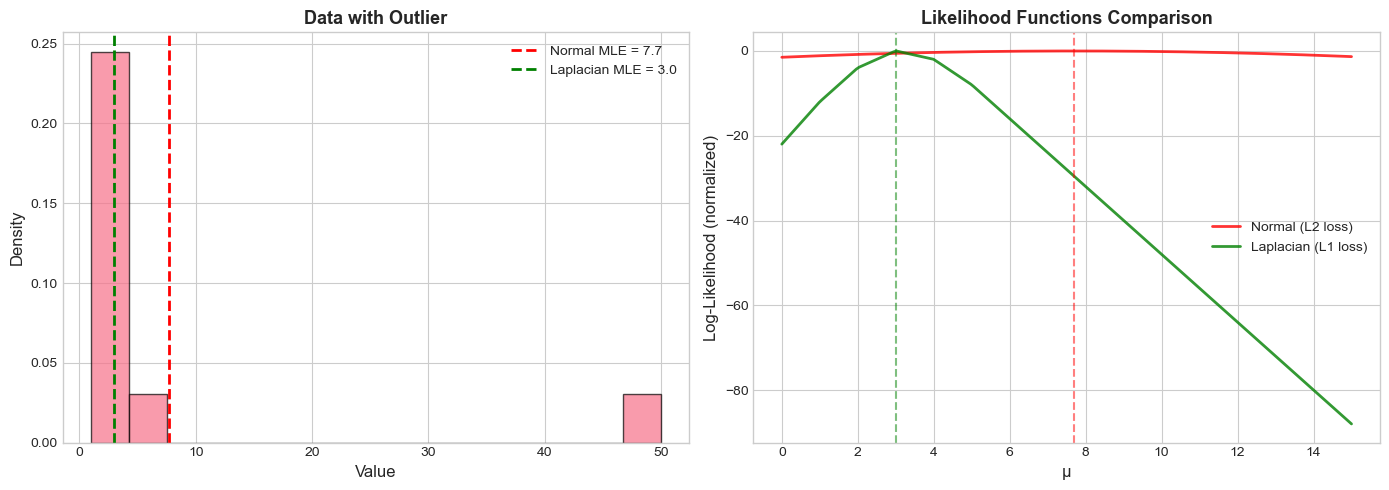


💡 Lesson Learned
──────────────────────────────────────────────────
  • Wrong distributional assumption → Poor estimates
  • Normal distribution is sensitive to outliers (L2 loss = squared penalty)
  • Laplacian distribution is robust (L1 loss = absolute penalty)
  • Always check your assumptions!
──────────────────────────────────────────────────


In [18]:
# When MLE Fails: Outliers with Normal Assumption
data_with_outlier = np.array([1, 2, 2, 3, 3, 3, 4, 4, 5, 50])

mu_normal = np.mean(data_with_outlier)
mu_laplace = np.median(data_with_outlier)

print("⚠️ MLE Failure: Heavy-Tailed Data")
print("═" * 50)
print(f"Data: {data_with_outlier}")
print(f"   Note the outlier: 50")
print(f"\nNormal MLE (mean): μ̂ = {mu_normal:.1f}")
print(f"   → Heavily influenced by outlier!")
print(f"\nLaplacian MLE (median): μ̂ = {mu_laplace:.1f}")
print(f"   → Robust to outliers!")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(data_with_outlier, bins=15, alpha=0.7, edgecolor='black', density=True)
ax1.axvline(mu_normal, color='red', linestyle='--', linewidth=2, label=f'Normal MLE = {mu_normal:.1f}')
ax1.axvline(mu_laplace, color='green', linestyle='--', linewidth=2, label=f'Laplacian MLE = {mu_laplace:.1f}')
ax1.set_xlabel('Value', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Data with Outlier', fontsize=13, fontweight='bold')
ax1.legend()

mu_range = np.linspace(0, 15, 200)
sigma = np.std(data_with_outlier)

log_lik_normal = [-0.5 * np.sum(((data_with_outlier - mu) / sigma)**2) for mu in mu_range]
log_lik_laplace = [-np.sum(np.abs(data_with_outlier - mu)) for mu in mu_range]

log_lik_normal = np.array(log_lik_normal) - max(log_lik_normal)
log_lik_laplace = np.array(log_lik_laplace) - max(log_lik_laplace)

ax2.plot(mu_range, log_lik_normal, 'r-', linewidth=2, label='Normal (L2 loss)', alpha=0.8)
ax2.plot(mu_range, log_lik_laplace, 'g-', linewidth=2, label='Laplacian (L1 loss)', alpha=0.8)
ax2.axvline(mu_normal, color='red', linestyle='--', alpha=0.5)
ax2.axvline(mu_laplace, color='green', linestyle='--', alpha=0.5)
ax2.set_xlabel('μ', fontsize=12)
ax2.set_ylabel('Log-Likelihood (normalized)', fontsize=12)
ax2.set_title('Likelihood Functions Comparison', fontsize=13, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print_box("Lesson Learned", [
    "Wrong distributional assumption → Poor estimates",
    "Normal distribution is sensitive to outliers (L2 loss = squared penalty)",
    "Laplacian distribution is robust (L1 loss = absolute penalty)",
    "Always check your assumptions!"
], "💡")

---
<a id='part8'></a>
# Part VIII: Model Diagnostics

Always check if your distributional assumption is reasonable!

## Q-Q Plots

Test 1: Data from Normal Distribution


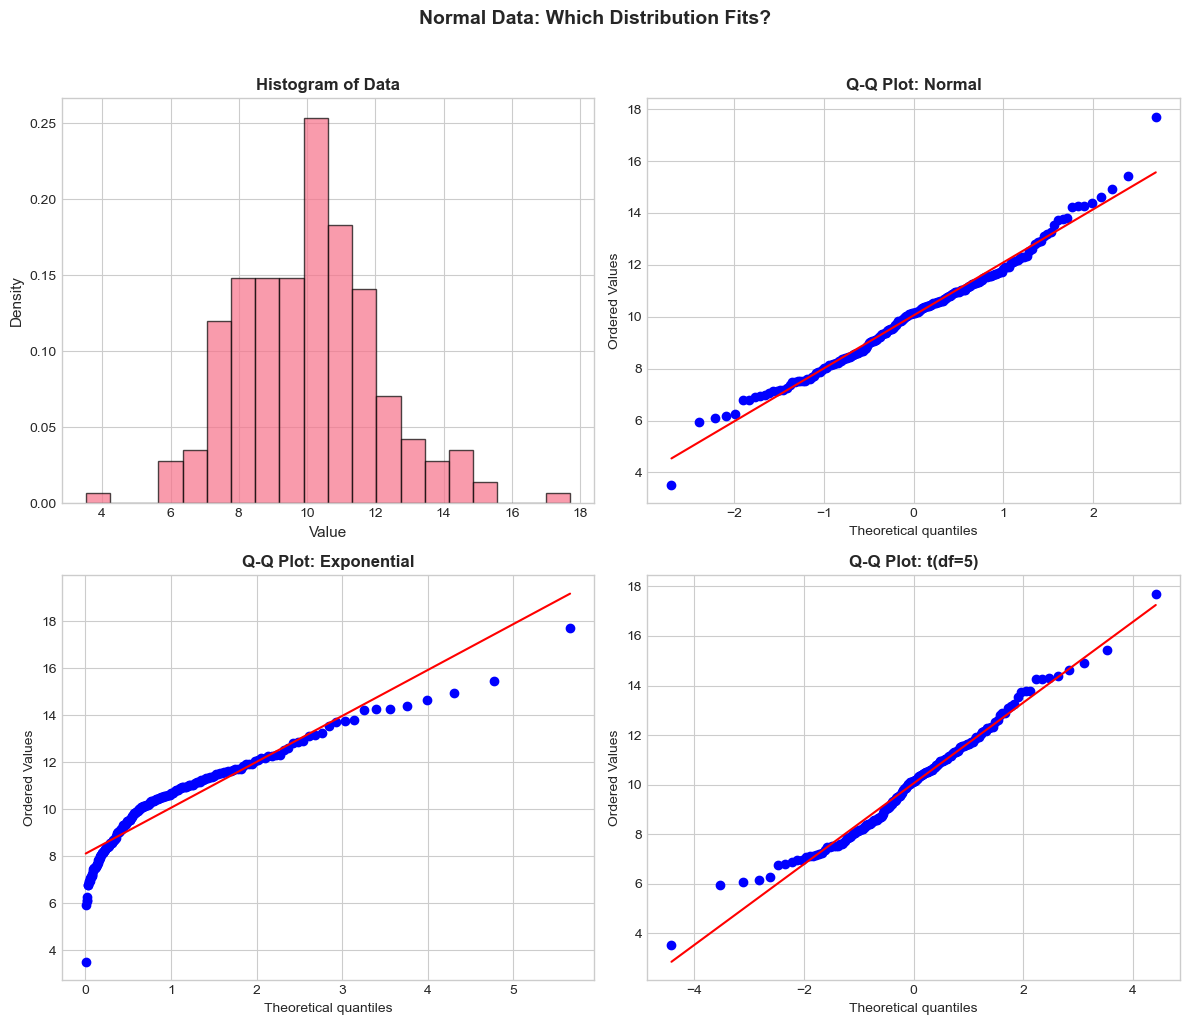


Test 2: Data from Heavy-tailed Distribution


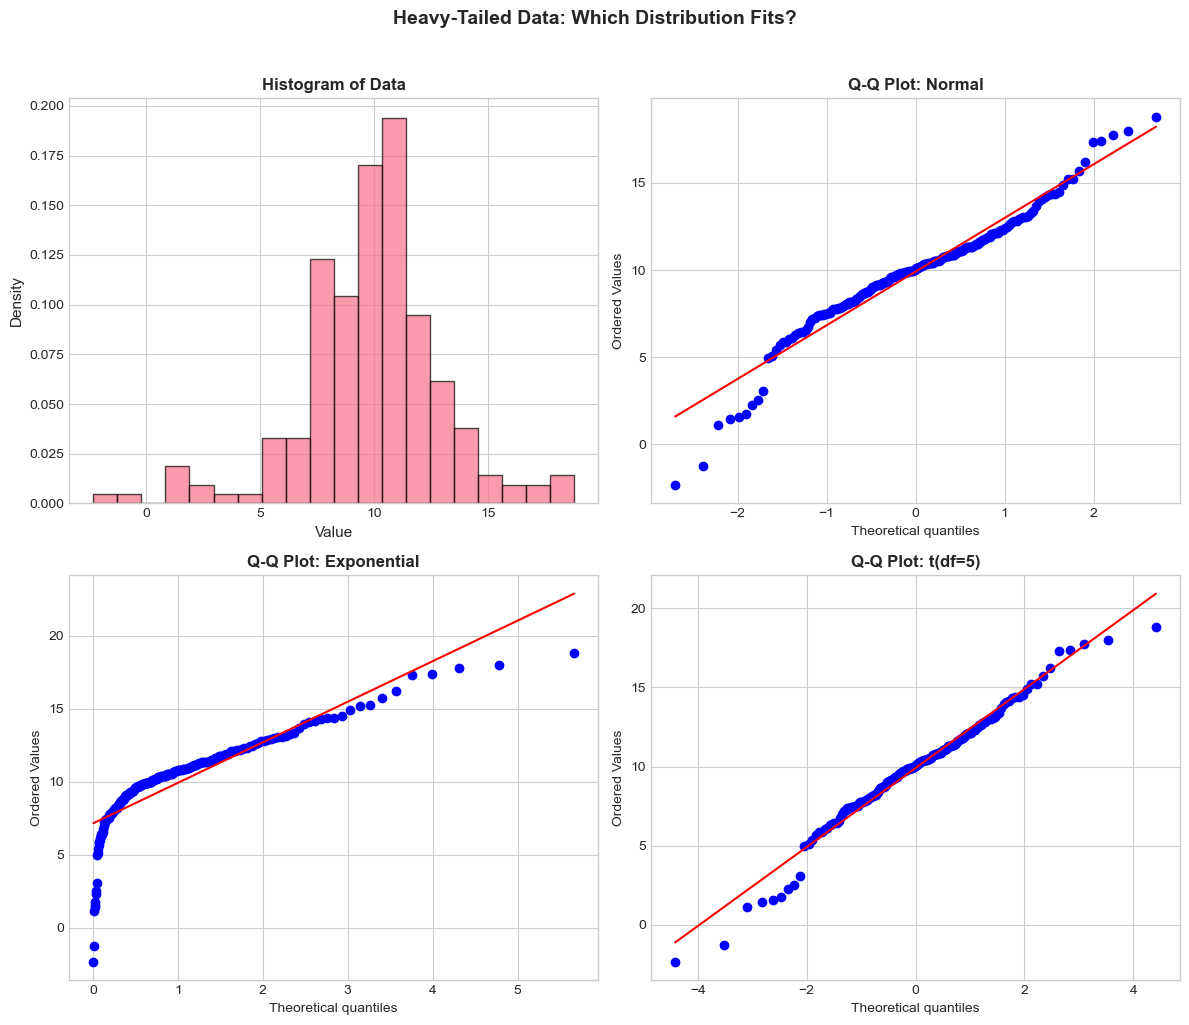


🔍 How to Interpret Q-Q Plots
──────────────────────────────────────────────────
  • Points on the diagonal line → Good fit
  • S-shaped deviation → Wrong distribution family
  • Tails deviating upward → Heavier tails than assumed
  • Tails deviating downward → Lighter tails than assumed
──────────────────────────────────────────────────


In [19]:
# Model Diagnostics: Q-Q Plots
def compare_distributions_qq(data, title="Distribution Comparison"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].hist(data, bins=20, alpha=0.7, edgecolor='black', density=True)
    axes[0, 0].set_xlabel('Value', fontsize=11)
    axes[0, 0].set_ylabel('Density', fontsize=11)
    axes[0, 0].set_title('Histogram of Data', fontsize=12, fontweight='bold')
    
    stats.probplot(data, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Q-Q Plot: Normal', fontsize=12, fontweight='bold')
    
    stats.probplot(data, dist="expon", plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q Plot: Exponential', fontsize=12, fontweight='bold')
    
    stats.probplot(data, dist="t", sparams=(5,), plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot: t(df=5)', fontsize=12, fontweight='bold')
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("Test 1: Data from Normal Distribution")
normal_data = np.random.normal(10, 2, 200)
compare_distributions_qq(normal_data, "Normal Data: Which Distribution Fits?")

print("\nTest 2: Data from Heavy-tailed Distribution")
heavy_tailed_data = np.random.standard_t(3, 200) * 2 + 10
compare_distributions_qq(heavy_tailed_data, "Heavy-Tailed Data: Which Distribution Fits?")

print_box("How to Interpret Q-Q Plots", [
    "Points on the diagonal line → Good fit",
    "S-shaped deviation → Wrong distribution family",
    "Tails deviating upward → Heavier tails than assumed",
    "Tails deviating downward → Lighter tails than assumed"
], "🔍")

---
<a id='exercises'></a>
# Practice Exercises with Solutions

## Exercise 1: Coin Flips

You flip a coin 20 times and observe 13 heads.

1. Compute the MLE for $p$
2. Plot the likelihood function
3. Compute a 95% confidence interval for $p$

Exercise 1: Coin Flips
══════════════════════════════════════════════════
Data: 13 heads in 20 flips

1. MLE: p̂ = k/n = 13/20 = 0.6500


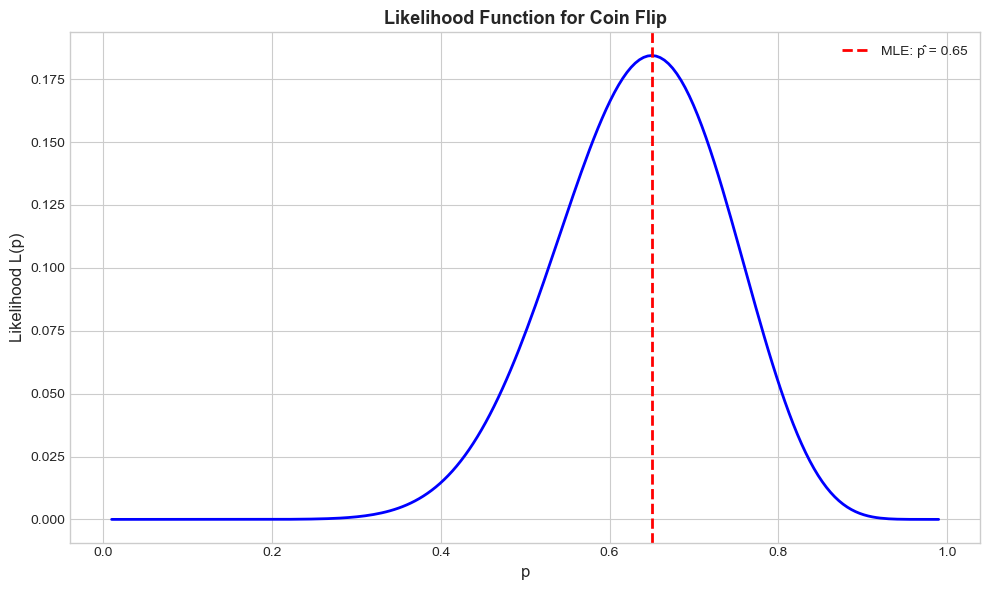


3. 95% Confidence Interval:
   Standard Error: SE = √[p̂(1-p̂)/n] = 0.1067
   CI: p̂ ± 1.96×SE = [0.4410, 0.8590]

   Interpretation: We are 95% confident the true probability
   of heads is between 44.1% and 85.9%


In [20]:
# Exercise 1: Solution
n = 20
k = 13

p_mle = k / n
print(f"Exercise 1: Coin Flips")
print("═" * 50)
print(f"Data: {k} heads in {n} flips")
print(f"\n1. MLE: p̂ = k/n = {k}/{n} = {p_mle:.4f}")

p_range = np.linspace(0.01, 0.99, 200)
likelihood = [comb(n, k) * p**k * (1-p)**(n-k) for p in p_range]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p_range, likelihood, 'b-', linewidth=2)
ax.axvline(p_mle, color='red', linestyle='--', linewidth=2, label=f'MLE: p̂ = {p_mle:.2f}')
ax.set_xlabel('p', fontsize=12)
ax.set_ylabel('Likelihood L(p)', fontsize=12)
ax.set_title('Likelihood Function for Coin Flip', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

se = np.sqrt(p_mle * (1 - p_mle) / n)
ci_lower = p_mle - 1.96 * se
ci_upper = p_mle + 1.96 * se

print(f"\n3. 95% Confidence Interval:")
print(f"   Standard Error: SE = √[p̂(1-p̂)/n] = {se:.4f}")
print(f"   CI: p̂ ± 1.96×SE = [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\n   Interpretation: We are 95% confident the true probability")
print(f"   of heads is between {ci_lower*100:.1f}% and {ci_upper*100:.1f}%")

## Exercise 2: Customer Arrivals

A store observes customer arrival counts per hour: [5, 3, 7, 4, 6, 5, 8, 4]

1. Fit a Poisson distribution
2. What's the probability of getting 10 or more customers in an hour?
3. Visualize the fitted distribution vs observed data

Exercise 2: Customer Arrivals
══════════════════════════════════════════════════
Data: [5 3 7 4 6 5 8 4]

1. Poisson MLE: λ̂ = x̄ = 5.25 customers/hour
   Mean = 5.25, Variance = 2.79
   Var/Mean = 0.53 ≈ 1 ✓ (Poisson appropriate)

2. P(X ≥ 10) = 1 - P(X ≤ 9) = 0.0418 = 4.18%


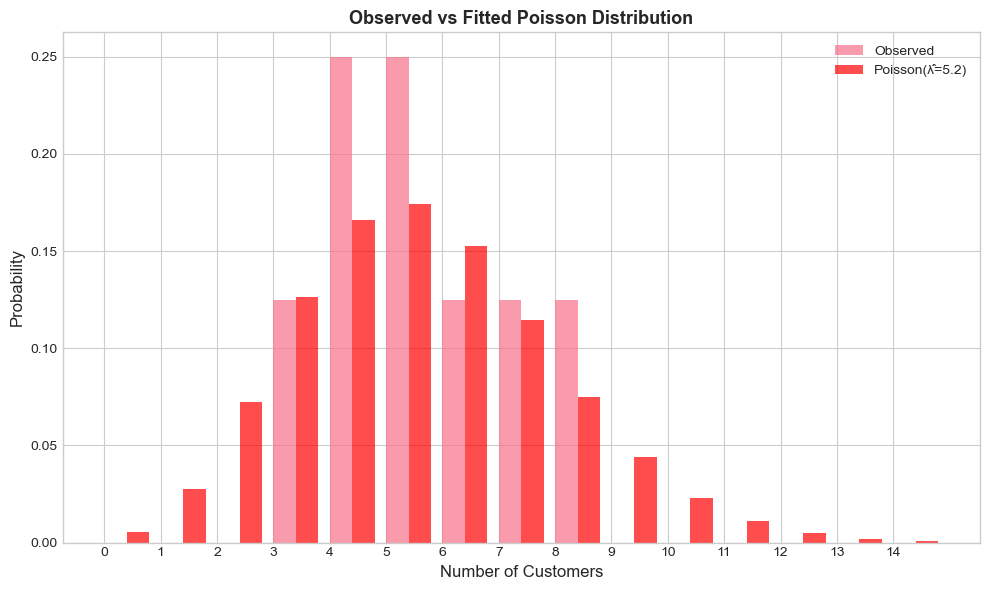

In [21]:
# Exercise 2: Solution
arrivals = np.array([5, 3, 7, 4, 6, 5, 8, 4])

print("Exercise 2: Customer Arrivals")
print("═" * 50)
print(f"Data: {arrivals}")

lambda_mle = np.mean(arrivals)
print(f"\n1. Poisson MLE: λ̂ = x̄ = {lambda_mle:.2f} customers/hour")

sample_var = np.var(arrivals, ddof=1)
print(f"   Mean = {lambda_mle:.2f}, Variance = {sample_var:.2f}")
print(f"   Var/Mean = {sample_var/lambda_mle:.2f} ≈ 1 ✓ (Poisson appropriate)")

prob_ge_10 = 1 - stats.poisson.cdf(9, lambda_mle)
print(f"\n2. P(X ≥ 10) = 1 - P(X ≤ 9) = {prob_ge_10:.4f} = {prob_ge_10*100:.2f}%")

fig, ax = plt.subplots(figsize=(10, 6))

x_vals = np.arange(0, 15)
hist_vals, _ = np.histogram(arrivals, bins=np.arange(-0.5, 15.5, 1), density=True)

ax.bar(x_vals[:len(hist_vals)], hist_vals, alpha=0.7, label='Observed', width=0.4, align='edge')

poisson_pmf = stats.poisson.pmf(x_vals, lambda_mle)
ax.bar(x_vals + 0.4, poisson_pmf, alpha=0.7, color='red', label=f'Poisson(λ̂={lambda_mle:.1f})', width=0.4, align='edge')

ax.set_xlabel('Number of Customers', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Observed vs Fitted Poisson Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xticks(x_vals)
plt.tight_layout()
plt.show()

---
<a id='summary'></a>
# Summary & Quick Reference

## Key Formulas

| Distribution | MLE Formula | Standard Error |
|-------------|-------------|----------------|
| **Bernoulli** | $\hat{p} = \bar{x}$ | $\sqrt{\hat{p}(1-\hat{p})/n}$ |
| **Poisson** | $\hat{\lambda} = \bar{x}$ | $\sqrt{\hat{\lambda}/n}$ |
| **Exponential** | $\hat{\lambda} = 1/\bar{x}$ | $\hat{\lambda}/\sqrt{n}$ |
| **Normal (μ)** | $\hat{\mu} = \bar{x}$ | $\hat{\sigma}/\sqrt{n}$ |
| **Normal (σ²)** | $\hat{\sigma}^2 = \frac{1}{n}\sum(x_i-\bar{x})^2$ | - |

## Key Concepts

1. **Likelihood ≠ Probability**: Likelihood ratios are meaningful, absolute values are not
2. **Log-likelihood**: Use it for numerical stability
3. **Score equation**: $s(\theta) = 0$ gives MLE (necessary condition)
4. **Fisher Information**: $I(\theta)$ determines variance of MLE
5. **Asymptotic properties**: Consistency, normality, efficiency
6. **Invariance**: $g(\hat{\theta}_{ML})$ is MLE of $g(\theta)$
7. **ML = LS** under Gaussian noise

---

<a id='glossary'></a>
# Glossary

| Term | Definition |
|------|------------|
| **Likelihood** | Function of parameters given fixed data: $L(\theta|x)$ |
| **Log-likelihood** | Natural log of likelihood: $\ell(\theta) = \log L(\theta)$ |
| **MLE** | Parameter value that maximizes the likelihood |
| **Score function** | Derivative of log-likelihood: $s(\theta) = \partial\ell/\partial\theta$ |
| **Fisher Information** | Expected curvature of log-likelihood; $I(\theta) = -E[\partial^2\ell/\partial\theta^2]$ |
| **Cramér-Rao Bound** | Lower bound on variance of unbiased estimators: $Var(\hat{\theta}) \geq 1/I(\theta)$ |
| **Consistency** | MLE converges to true value as $n \to \infty$ |
| **Efficiency** | MLE achieves Cramér-Rao bound asymptotically |
| **Invariance** | MLE of $g(\theta)$ is $g(\hat{\theta}_{ML})$ |
| **Bias** | $E[\hat{\theta}] - \theta$; MLE can be biased for finite samples |

---

**End of Notebook**  
*Course: TTK 4260 - Multivariate Data Analysis and ML*  
*Instructor: Adil Rasheed*